In [1]:
import os
import csv
import time
import psutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import dgl

from tqdm import tqdm
from collections import defaultdict
# =========================================================
# Standard Library
# =========================================================
import os
import time
import csv
import statistics
from collections import defaultdict

# =========================================================
# Numerical / Data
# =========================================================
import numpy as np
import pandas as pd
import scipy.stats
from scipy.stats import ttest_ind
from sklearn.metrics.pairwise import cosine_similarity

# =========================================================
# Machine Learning / Clustering
# =========================================================
from sklearn.cluster import SpectralBiclustering
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve
)

# =========================================================
# Visualization
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LogNorm, to_rgb
from matplotlib.ticker import LogFormatter, LogFormatterMathtext
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import plotly.graph_objects as go

# =========================================================
# Graph Libraries
# =========================================================
import networkx as nx
import igraph as ig
import leidenalg as la

import dgl
from torch_geometric.nn import GCNConv

# =========================================================
# Deep Learning
# =========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BCEWithLogitsLoss

# =========================================================
# Monitoring
# =========================================================
import psutil
from tqdm import tqdm

# =========================================================
# Dimensionality Reduction
# =========================================================
import umap


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dlopen(/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_sparse/_convert_cpu.so, 0x0006): Symbol not found: __ZN2at8internal15invoke_parallelExxxRKNSt3__18functionIFvxxEEE
  Referenced from: <B7A49972-B945-390D-952D-B14A1F34B4B7> /Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_sparse/_convert_cpu.so
  Expected in:     <F30C371B-792B-396A-93AB-5B28EF7BFD21> /Users/ericsali/miniforge3/envs/kg39/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [2]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# PROJECT IMPORTS
# =========================================================

from src.models import (
    ACGNN,
    HGDC,
    EMOGI,
    MTGCN,
    GCN,
    GAT,
    GraphSAGE,
    GIN,
    ChebNet,
    FocalLoss
)

from src.utils import (
    choose_model,
    plot_roc_curve,
    plot_pr_curve,
    load_graph_data
)

from src.train_cpdb_leiden_pass import (
# from src.train import (
    save_predicted_scores,
    save_average_scores,
    plot_average_scores,
    plot_score_distributions,
    save_performance_metrics,
    save_overall_metrics,
    process_predictions,
    generate_kde_and_curves,
    plot_degree_distributions,
    calculate_and_save_prediction_stats,
    plot_model_performance,
    plot_leiden_cancer_gene_heatmap,
    plot_leiden_gene_cancer_heatmap,
    plot_gene_cancer_biclustering_heatmap,
    plot_gene_cancer_biclustering_heatmap_with_gene_clusters,
    plot_leiden_cluster_cancer_sankey,
    compute_gene_saliency,
    leiden_cluster_gene_saliency,
    plot_gene_saliency_umap,
    plot_gene_umap,
    plot_umap_with_cluster_colors,
    split_gene_cancer_by_omics,
    leiden_bipartite_clustering,
    plot_omics_bipartite_heatmap,
    CLUSTER_COLORS
)

from src.utils import save_model_details


In [3]:
import torch

class Args:
    model_type = 'ACGNN'
    # net_type = 'CPDB'
    net_type = 'Pathway'
    hidden_feats = 128
    learning_rate = 1e-3
    num_epochs = 100
    score_threshold = 0.5
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

args = Args()

LEIDEN_RESOLUTION = 3.0

In [4]:
epoch_times = []
cpu_usages = []
gpu_usages = []

In [5]:
# =========================================================
# DIRECT GRAPH LOADER
# =========================================================

import os
import csv
import torch
import numpy as np
from tqdm.auto import tqdm
from collections import defaultdict

# =========================================================
# CONFIG
# =========================================================

MAX_EDGES_PER_NODE = 200 

source_csv_path = (
    "../process/data/processed/"
    "omics_pretrained_embeddings.csv"
)

target_csv_path = (
    "../process/data/processed/"
    "omics_pretrained_embeddings.csv"
)

relation_csv_path = (
    "../process/data/processed/"
    "gene_pairs_limit5000.csv"
)

SAVE_GRAPH_PATH = (
    "../process/data/processed/"
    "gene_graph_direct.pt"
)

interaction_labels = {
    "0": 0,
    "1": 1,
    "2": -1,
    "3": -1
}

def count_lines(file_path):
    with open(file_path) as f:
        return sum(1 for _ in f) - 1


# =========================================================
# LOAD EMBEDDINGS
# =========================================================

def read_embeddings(file_path):
    embeddings = {}
    total = count_lines(file_path)
    with open(file_path, newline='') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)
        for row in tqdm(
            reader,
            total=total,
            desc=f"Embeddings: {os.path.basename(file_path)}",
            colour="green"
        ):

            name = row[0]

            emb = np.array(
                row[1:],
                dtype=np.float32
            )

            # ------------------------------------------------
            # Clean NaN / Inf
            # ------------------------------------------------

            emb = np.nan_to_num(
                emb,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            embeddings[name] = emb.tolist()

    return embeddings


# =========================================================
# MAIN GRAPH LOADER
# =========================================================

def load_graph_data_directly(
    source_csv_path,
    target_csv_path,
    relation_csv_path,
    max_edges_per_node=15
):

    print("\n====================================")
    print("[INFO] Loading embeddings...")
    print("====================================")

    source_embeddings = read_embeddings(
        source_csv_path
    )
    target_embeddings = read_embeddings(
        target_csv_path
    )

    # =====================================================
    # LOAD RELATIONSHIPS
    # =====================================================

    print("\n====================================")
    print("[INFO] Reading relationships...")
    print("====================================")

    node_edges = defaultdict(list)
    nodes_set = set()
    total_rel = count_lines(
        relation_csv_path
    )
    with open(
        relation_csv_path,
        newline=''
    ) as csvfile:
        reader = csv.DictReader(csvfile)
        for row in tqdm(
            reader,
            total=total_rel,
            desc="Reading edges",
            colour="cyan"
        ):
            s = row["Gene1"]
            t = row["Gene2"]
            rel = str(
                row["gene_type"]
            )
            if rel not in interaction_labels:
                continue

            score = interaction_labels[rel]

            # ------------------------------------------------
            # SAME AS ORIGINAL JSON STRUCTURE
            # ------------------------------------------------
            source_label = score
            target_label = (
                1 if rel == "2"
                else 0 if rel == "0"
                else -1
            )
            node_edges[s].append(
                (
                    t,
                    rel,
                    source_label,
                    target_label
                )
            )
            node_edges[t].append(
                (
                    s,
                    rel,
                    target_label,
                    source_label
                )
            )
            nodes_set.update([s, t])

    # =====================================================
    # PRUNE GRAPH
    # =====================================================

    print("\n====================================")
    print("[INFO] Pruning graph...")
    print("====================================")

    filtered_edges = []
    for node, neighbors in tqdm(
        node_edges.items(),
        total=len(node_edges),
        desc="Pruning edges",
        colour="yellow"
    ):
        neighbors = neighbors[
            :max_edges_per_node
        ]
        for (
            tgt,
            rel,
            source_label,
            target_label
        ) in neighbors:
            filtered_edges.append(
                (
                    node,
                    tgt,
                    rel,
                    source_label,
                    target_label
                )
            )

    print(
        f"\n[INFO] Edges after pruning: "
        f"{len(filtered_edges)}"
    )

    # =====================================================
    # ENSURE CONNECTIVITY
    # =====================================================

    print("\n====================================")
    print("[INFO] Reconnecting isolated nodes...")
    print("====================================")

    connected = set()
    for s, t, _, _, _ in tqdm(
        filtered_edges,
        total=len(filtered_edges),
        desc="Checking connectivity",
        colour="magenta"
    ):
        connected.add(s)
        connected.add(t)
    isolated_count = 0

    for node in tqdm(
        nodes_set,
        total=len(nodes_set),
        desc="Reconnecting isolated",
        colour="red"
    ):
        if node not in connected:
            if (
                node in node_edges
                and len(node_edges[node]) > 0
            ):
                filtered_edges.append(
                    (
                        node,
                        *node_edges[node][0]
                    )
                )
                isolated_count += 1

    print(
        f"\n[INFO] Reconnected isolated nodes: "
        f"{isolated_count}"
    )

    print(
        f"[INFO] Final edges: "
        f"{len(filtered_edges)}"
    )

    # =====================================================
    # BUILD GRAPH
    # =====================================================

    print("\n====================================")
    print("[INFO] Constructing graph...")
    print("====================================")

    nodes = {}
    edges = []
    labels = []
    embeddings = []
    skipped_edges = 0

    for (
        s,
        t,
        rel,
        source_label,
        target_label
    ) in tqdm(
        filtered_edges,
        total=len(filtered_edges),
        desc="Constructing graph",
        colour="blue"
    ):

        # ------------------------------------------------
        # Skip missing embeddings
        # ------------------------------------------------

        if (
            s not in source_embeddings
            or t not in target_embeddings
        ):

            skipped_edges += 1
            continue

        # =================================================
        # SOURCE NODE
        # =================================================

        if s not in nodes:
            nodes[s] = len(nodes)
            embeddings.append(
                source_embeddings[s]
            )

            labels.append(
                source_label
                if source_label is not None
                else -1
            )

        # =================================================
        # TARGET NODE
        # =================================================

        if t not in nodes:
            nodes[t] = len(nodes)
            embeddings.append(
                target_embeddings[t]
            )

            labels.append(
                target_label
                if target_label is not None
                else -1
            )

        # =================================================
        # EDGE
        # =================================================

        edges.append(
            (
                nodes[s],
                nodes[t]
            )
        )

    print(
        f"\n[INFO] Skipped edges: "
        f"{skipped_edges}"
    )

    # =====================================================
    # CONVERT TO TENSORS
    # =====================================================

    print("\n====================================")
    print("[INFO] Converting to tensors...")
    print("====================================")

    embeddings_tensor = torch.tensor(
        np.array(embeddings),
        dtype=torch.float32
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long
    )

    # =====================================================
    # SUMMARY
    # =====================================================

    print("\n====================================")
    print("[INFO] GRAPH SUMMARY")
    print("====================================")

    print(f"Nodes: {len(nodes)}")

    print(f"Edges: {len(edges)}")

    print(
        f"Embedding tensor shape: "
        f"{embeddings_tensor.shape}"
    )

    print(
        f"Labels tensor shape: "
        f"{labels_tensor.shape}"
    )

    # =====================================================
    # SAVE
    # =====================================================

    print("\n====================================")
    print("[INFO] Saving graph...")
    print("====================================")

    save_obj = {

        "nodes": nodes,
        "edges": edges,

        "embeddings_tensor": embeddings_tensor,

        "labels_tensor": labels_tensor
    }

    torch.save(
        save_obj,
        SAVE_GRAPH_PATH
    )

    print(f"\nGraph saved:")
    print(SAVE_GRAPH_PATH)

    return (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    )


# =========================================================
# LOAD GRAPH
# =========================================================

(
    nodes,
    edges,
    embeddings_tensor,
    labels_tensor
) = load_graph_data_directly(

    source_csv_path=source_csv_path,

    target_csv_path=target_csv_path,

    relation_csv_path=relation_csv_path,

    max_edges_per_node=MAX_EDGES_PER_NODE
)

# =========================================================
# LOAD SAVED GRAPH
# =========================================================

print("\n====================================")
print("[INFO] Reloading saved graph...")
print("====================================")

loaded_graph = torch.load(
    SAVE_GRAPH_PATH,
    map_location="cpu"
)

nodes = loaded_graph["nodes"]

edges = loaded_graph["edges"]

embeddings = loaded_graph[
    "embeddings_tensor"
]

labels = loaded_graph[
    "labels_tensor"
]


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/490438 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/9080 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 490438

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/490438 [00:00<?, ?it/s]


[INFO] Skipped edges: 258144

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5809
Edges: 232294
Embedding tensor shape: torch.Size([5809, 2688])
Labels tensor shape: torch.Size([5809])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt

[INFO] Reloading saved graph...


In [6]:
if isinstance(nodes, dict):
    node_names = list(nodes.keys())
elif isinstance(nodes, (list, np.ndarray)):
    node_names = list(nodes)
else:
    node_names = list(nodes)

node_names = np.array(node_names)

In [7]:
graph = dgl.graph(edges)

graph.ndata['feat'] = embeddings
graph.ndata['label'] = labels

In [8]:
from sklearn.model_selection import train_test_split

# ============================================================
# LABELED NODES ONLY
# ============================================================

labeled_idx = torch.where(
    labels != -1
)[0]

labeled_labels = labels[
    labeled_idx
].cpu().numpy()

# ============================================================
# TRAIN / TEMP
# ============================================================

train_idx_np, temp_idx_np = train_test_split(
    labeled_idx.cpu().numpy(),
    test_size=0.40,
    stratify=labeled_labels,
    random_state=42
)

# ============================================================
# VALIDATION / TEST
# ============================================================

temp_labels = labels[
    temp_idx_np
].cpu().numpy()

val_idx_np, test_idx_np = train_test_split(
    temp_idx_np,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

# ============================================================
# CONVERT TO TORCH
# ============================================================

train_idx = torch.tensor(
    train_idx_np,
    dtype=torch.long
)

val_idx = torch.tensor(
    val_idx_np,
    dtype=torch.long
)

test_idx = torch.tensor(
    test_idx_np,
    dtype=torch.long
)

# ============================================================
# MASKS
# ============================================================

train_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# ============================================================
# STORE IN GRAPH
# ============================================================

graph.ndata["train_mask"] = train_mask
graph.ndata["val_mask"] = val_mask
graph.ndata["test_mask"] = test_mask

# ============================================================
# SUMMARY
# ============================================================

print("Train:", train_mask.sum().item())
print("Validation:", val_mask.sum().item())
print("Test:", test_mask.sum().item())

Train: 2457
Validation: 819
Test: 820


In [9]:
print("train:", train_mask.sum().item())
print("val  :", val_mask.sum().item())
print("test :", test_mask.sum().item())

print("train-val :", (train_mask & val_mask).sum().item())
print("train-test:", (train_mask & test_mask).sum().item())
print("val-test  :", (val_mask & test_mask).sum().item())

train: 2457
val  : 819
test : 820
train-val : 0
train-test: 0
val-test  : 0


In [10]:
# ============================================================
# MASKS
# ============================================================

train_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# ============================================================
# VERIFY SPLITS
# ============================================================

print("Train:", train_mask.sum().item())
print("Val  :", val_mask.sum().item())
print("Test :", test_mask.sum().item())

print(
    "train-val :",
    (train_mask & val_mask).sum().item()
)

print(
    "train-test:",
    (train_mask & test_mask).sum().item()
)

print(
    "val-test  :",
    (val_mask & test_mask).sum().item()
)

# ============================================================
# STORE IN GRAPH
# ============================================================

graph.ndata["train_mask"] = train_mask
graph.ndata["val_mask"] = val_mask
graph.ndata["test_mask"] = test_mask

Train: 2457
Val  : 819
Test : 820
train-val : 0
train-test: 0
val-test  : 0


In [11]:
print(
    "Total labeled:",
    len(labeled_idx)
)

print(
    "Split total:",
    train_mask.sum().item()
    + val_mask.sum().item()
    + test_mask.sum().item()
)

membership = (
    train_mask.int()
    + val_mask.int()
    + test_mask.int()
)

print(
    "Nodes assigned more than once:",
    (membership > 1).sum().item()
)

print(
    "Labeled nodes not assigned:",
    (membership[labeled_idx] == 0).sum().item()
)


Total labeled: 4096
Split total: 4096
Nodes assigned more than once: 0
Labeled nodes not assigned: 0


In [12]:
# train_mask = labels != -1
# test_mask = torch.ones_like(labels, dtype=torch.bool)
graph.ndata['train_mask'] = train_mask
graph.ndata['test_mask'] = test_mask

graph = dgl.add_self_loop(graph)

In [13]:
in_feats = embeddings.shape[1]
hidden_feats = args.hidden_feats
out_feats = 1

In [14]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

graph = graph.to(device)

features = graph.ndata['feat'].to(device)
labels = graph.ndata['label'].to(device).float()

train_mask = graph.ndata['train_mask'].to(device)
test_mask = graph.ndata['test_mask'].to(device)

In [15]:
train_mask = graph.ndata['train_mask'].to(device)
val_mask = graph.ndata['val_mask'].to(device)
test_mask = graph.ndata['test_mask'].to(device)

In [16]:
model = choose_model(
    args.model_type,
    in_feats,
    hidden_feats,
    out_feats
).to(device)

In [17]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=args.learning_rate
)

loss_fn = FocalLoss(
    alpha=0.25,
    gamma=2
)

In [18]:
output_dir = 'results/gene_prediction/'
os.makedirs(output_dir, exist_ok=True)

model_csv_path = os.path.join(
    output_dir,
    f'{args.model_type}_model_structure.csv'
)

In [19]:
print(f"Starting training for {args.num_epochs} epochs...")

for epoch in tqdm(
    range(args.num_epochs),
    desc="Training Progress"
):

    start_time = time.time()

    model.train()

    logits = model(graph, features).squeeze()

    loss = loss_fn(
        logits[train_mask],
        labels[train_mask]
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    tqdm.write(
        f"Epoch {epoch+1}/{args.num_epochs} | "
        f"Loss={loss.item():.4f} | "
        f"Time={epoch_time:.2f}s"
    )

Starting training for 100 epochs...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 | Loss=0.0435 | Time=0.72s
Epoch 2/100 | Loss=0.0411 | Time=0.59s
Epoch 3/100 | Loss=0.0380 | Time=0.58s
Epoch 4/100 | Loss=0.0347 | Time=0.60s
Epoch 5/100 | Loss=0.0310 | Time=0.58s
Epoch 6/100 | Loss=0.0274 | Time=0.58s
Epoch 7/100 | Loss=0.0246 | Time=0.62s
Epoch 8/100 | Loss=0.0232 | Time=0.59s
Epoch 9/100 | Loss=0.0219 | Time=0.76s
Epoch 10/100 | Loss=0.0206 | Time=0.57s
Epoch 11/100 | Loss=0.0193 | Time=0.57s
Epoch 12/100 | Loss=0.0185 | Time=0.63s
Epoch 13/100 | Loss=0.0175 | Time=0.56s
Epoch 14/100 | Loss=0.0166 | Time=0.57s
Epoch 15/100 | Loss=0.0156 | Time=0.57s
Epoch 16/100 | Loss=0.0153 | Time=0.60s
Epoch 17/100 | Loss=0.0149 | Time=0.63s
Epoch 18/100 | Loss=0.0140 | Time=0.59s
Epoch 19/100 | Loss=0.0136 | Time=0.58s
Epoch 20/100 | Loss=0.0133 | Time=0.59s
Epoch 21/100 | Loss=0.0122 | Time=0.57s
Epoch 22/100 | Loss=0.0115 | Time=0.58s
Epoch 23/100 | Loss=0.0115 | Time=0.61s
Epoch 24/100 | Loss=0.0105 | Time=0.59s
Epoch 25/100 | Loss=0.0104 | Time=0.60s
Epoch 26/

In [20]:
model.eval()

with torch.no_grad():

    logits = model(graph, features).squeeze()

    scores = torch.sigmoid(
        logits
    ).detach().cpu().numpy()

In [21]:
model.eval()

with torch.no_grad():

    probs = torch.sigmoid(
        logits
    )

    val_labels = labels[
        val_mask
    ].cpu().numpy()

    val_scores = probs[
        val_mask
    ].cpu().numpy()

    val_auc = roc_auc_score(
        val_labels,
        val_scores
    )

    val_aupr = average_precision_score(
        val_labels,
        val_scores
    )

tqdm.write(
    f"Epoch {epoch+1}/{args.num_epochs} | "
    f"Loss={loss.item():.4f} | "
    f"Val AUROC={val_auc:.4f} | "
    f"Val AUPRC={val_aupr:.4f}"
)

Epoch 100/100 | Loss=0.0000 | Val AUROC=0.9080 | Val AUPRC=0.9086


In [22]:
print(
    labels[train_mask].sum().item(),
    labels[val_mask].sum().item()
)

overlap = (
    train_mask & val_mask
).sum()

print("Overlap:", overlap)

print("train-val :", (train_mask & val_mask).sum().item())
print("train-test:", (train_mask & test_mask).sum().item())
print("val-test  :", (val_mask & test_mask).sum().item())

1366.0 455.0
Overlap: tensor(0)
train-val : 0
train-test: 0
val-test  : 0


In [23]:
# model.eval()

# with torch.no_grad():

#     logits = model(
#         graph,
#         features
#     ).squeeze()

#     probs = torch.sigmoid(
#         logits
#     )

# # ============================================================
# # TEST PERFORMANCE
# # ============================================================

# test_labels = labels[
#     test_mask
# ].cpu().numpy()

# test_scores = probs[
#     test_mask
# ].cpu().numpy()

# test_auc = roc_auc_score(
#     test_labels,
#     test_scores
# )

# test_aupr = average_precision_score(
#     test_labels,
#     test_scores
# )

# print("\n================================")
# print(f"Test AUROC : {test_auc:.4f}")
# print(f"Test AUPRC : {test_aupr:.4f}")
# print("================================")

In [24]:
test_labels = labels[test_mask].cpu().numpy()
test_scores = probs[test_mask].cpu().numpy()

# keep only labeled nodes
valid_idx = test_labels >= 0

test_labels = test_labels[valid_idx]
test_scores = test_scores[valid_idx]

test_auc = roc_auc_score(
    test_labels,
    test_scores
)

test_aupr = average_precision_score(
    test_labels,
    test_scores
)

In [25]:
print("Logits:", logits.shape)
print("Unique labels:", np.unique(labels.cpu().numpy()))

Logits: torch.Size([5809])
Unique labels: [-1.  0.  1.]


In [26]:
# # ============================================================
# # PREDICT UNLABELED GENES
# # ============================================================

# unlabeled_mask = labels == -1

# candidate_scores = probs[
#     unlabeled_mask
# ].cpu().numpy()

# candidate_nodes = np.where(
#     unlabeled_mask.cpu().numpy()
# )[0]

# # node names
# candidate_gene_names = [
#     nodes[i]
#     for i in candidate_nodes
# ]

# # rank
# ranking = sorted(
#     zip(
#         candidate_gene_names,
#         candidate_scores
#     ),
#     key=lambda x: x[1],
#     reverse=True
# )

# print("\nTop 20 predicted genes:\n")

# for gene, score in ranking[:20]:
#     print(
#         f"{gene:20s} {score:.4f}"
#     )

In [27]:
print(type(nodes))

if isinstance(nodes, dict):
    print("Example:", list(nodes.items())[:10])
else:
    print(nodes[:10])

<class 'dict'>
Example: [('AKT1', 0), ('ADD1', 1), ('ADRM1', 2), ('AKT2', 3), ('AKT3', 4), ('AVEN', 5), ('BAK1', 6), ('BAX', 7), ('BBC3', 8), ('BCL2', 9)]


In [28]:
# ============================================================
# NODE ID -> GENE NAME
# ============================================================

id_to_gene = {
    idx: gene
    for gene, idx in nodes.items()
}

# ============================================================
# PREDICT UNLABELED GENES
# ============================================================

unlabeled_mask = labels == -1

candidate_scores = probs[
    unlabeled_mask
].cpu().numpy()

candidate_nodes = np.where(
    unlabeled_mask.cpu().numpy()
)[0]

candidate_gene_names = [
    id_to_gene[i]
    for i in candidate_nodes
]

ranking = sorted(
    zip(
        candidate_gene_names,
        candidate_scores
    ),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop 20 predicted genes:\n")

for gene, score in ranking[:20]:
    print(
        f"{gene:20s} {score:.4f}"
    )

    
node_names = [
    gene
    for gene, idx in sorted(
        nodes.items(),
        key=lambda x: x[1]
    )
]

candidate_gene_names = [
    node_names[i]
    for i in candidate_nodes
]

print(id_to_gene[0])   # SUMF2
print(id_to_gene[1])   # SUMF1
print(id_to_gene[2])   # DVL2


Top 20 predicted genes:

AKT1                 1.0000
AKT2                 1.0000
AKT3                 1.0000
BCL2                 1.0000
CASP3                1.0000
CASP8                1.0000
CASP9                1.0000
CDKN2A               1.0000
MAPK1                1.0000
TP53                 1.0000
YWHAE                1.0000
RAP1B                1.0000
COL1A1               1.0000
ITGB1                1.0000
GLG1                 1.0000
F2RL3                1.0000
GNAS                 1.0000
SLC7A11              1.0000
L1CAM                1.0000
EGFR                 1.0000
AKT1
ADD1
ADRM1


In [29]:
print("Logit range:")
print(logits.min().item())
print(logits.max().item())

print("\nTop logits:")

top_idx = torch.argsort(logits, descending=True)[:20]

for idx in top_idx:
    print(
        id_to_gene[int(idx)],
        logits[idx].item()
    )

Logit range:
-13.50573444366455
158.3362274169922

Top logits:
GNAS 158.3362274169922
PRKACA 126.70548248291016
PIK3R2 115.85930633544922
RAF1 112.2550048828125
PIK3CA 111.57109832763672
SGK1 110.67439270019531
ATP2B3 110.07730865478516
RUNX1 103.22075653076172
SLC34A2 102.25532531738281
PRKAR1A 100.89307403564453
TFRC 100.5459213256836
CTNNB1 97.6937484741211
NGB 93.38168334960938
AKT1 90.85543060302734
ADI1 90.60601043701172
WNK2 89.894287109375
GNA11 89.84152221679688
ITGB1 89.72357940673828
ABL1 89.37001037597656
YAP1 86.12700653076172


In [30]:
print(
    "Probabilities:",
    probs.min().item(),
    probs.max().item()
)

preds = (probs > 0.5).float()

print(
    "Predicted positives:",
    preds.sum().item(),
    "/",
    len(preds)
)

valid = labels >= 0

y = labels[valid]

print("Positives:", (y == 1).sum().item())
print("Negatives:", (y == 0).sum().item())

Probabilities: 1.3631180308948387e-06 1.0
Predicted positives: 3636.0 / 5809
Positives: 2277
Negatives: 1819



Running fixed-k ablation...

Evaluating fixed k = 1

Evaluating fixed k = 2

Evaluating fixed k = 3

Evaluating fixed k = 4

Evaluating fixed k = 5

Evaluating adaptive PISGE

Ablation Results


,Model,AUROC,AUPRC
0,k=1,0.558021,0.621169
1,k=2,0.893562,0.918989
2,k=3,0.900421,0.895968
3,k=4,0.942386,0.961548
4,k=5,0.947073,0.965309
5,Adaptive,0.950161,0.962999


Saved: results/gene_prediction/PISGE_depth_ablation.csv


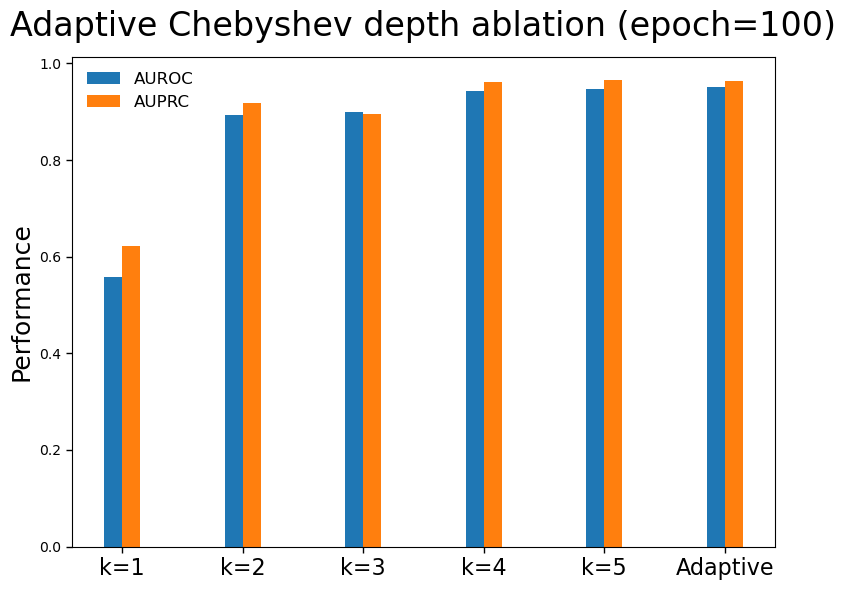

Saved: results/gene_prediction/ACGNN_depth_ablation.png


In [31]:
# ============================================================
# ABLATION:
# EFFECT OF ADAPTIVE CHEBYSHEV DEPTH
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ============================================================
# TRAIN + EVALUATE
# ============================================================

def run_ablation_model(
    model,
    graph,
    features,
    labels,
    train_mask,
    epochs=50,
    lr=1e-3
):

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # ----------------------------------------
    # Train
    # ----------------------------------------

    for epoch in range(epochs):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # ----------------------------------------
    # Evaluate
    # ----------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

    y_true = labels[
        test_mask
    ].cpu().numpy()

    y_score = probs[
        test_mask
    ].cpu().numpy()

    auc = roc_auc_score(
        y_true,
        y_score
    )

    aupr = average_precision_score(
        y_true,
        y_score
    )

    return auc, aupr


# ============================================================
# RUN FIXED-k MODELS
# ============================================================

results = []

fixed_k_values = [1, 2, 3, 4, 5]

print("\nRunning fixed-k ablation...")

for k_val in fixed_k_values:

    print(f"\nEvaluating fixed k = {k_val}")

    model = ACGNN(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=1,
        k=k_val,
        epsilon=0.0      # disables adaptive stopping
    )

    auc, aupr = run_ablation_model(
        model,
        graph,
        features,
        labels,
        train_mask,
        epochs=args.num_epochs,
        lr=args.learning_rate
    )

    results.append({
        "Model": f"k={k_val}",
        "AUROC": auc,
        "AUPRC": aupr
    })


# ============================================================
# ADAPTIVE MODEL
# ============================================================

print("\nEvaluating adaptive PISGE")

adaptive_model = ACGNN(
    in_feats=in_feats,
    hidden_feats=hidden_feats,
    out_feats=1,
    k=5,                # maximum depth allowed
    epsilon=1e-4        # adaptive stopping
)

auc, aupr = run_ablation_model(
    adaptive_model,
    graph,
    features,
    labels,
    train_mask,
    epochs=args.num_epochs,
    lr=args.learning_rate
)

results.append({
    "Model": "Adaptive",
    "AUROC": auc,
    "AUPRC": aupr
})


# ============================================================
# RESULTS TABLE
# ============================================================

ablation_df = pd.DataFrame(
    results
)

print("\nAblation Results")
display(ablation_df)

ablation_csv = os.path.join(
    output_dir,
    "PISGE_depth_ablation.csv" 
)

ablation_df.to_csv(
    ablation_csv,
    index=False
)

print(
    f"Saved: {ablation_csv}"
)


# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,6)
)

x = np.arange(
    len(ablation_df)
)

width = 0.15

ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC"
)

ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC"
)

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_title(
    f"Adaptive Chebyshev depth ablation (epoch={args.num_epochs})",
    fontsize=24,
    pad=15
)

ax.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=1
)

ax.legend(
    frameon=False,
    fontsize=12
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_depth_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)

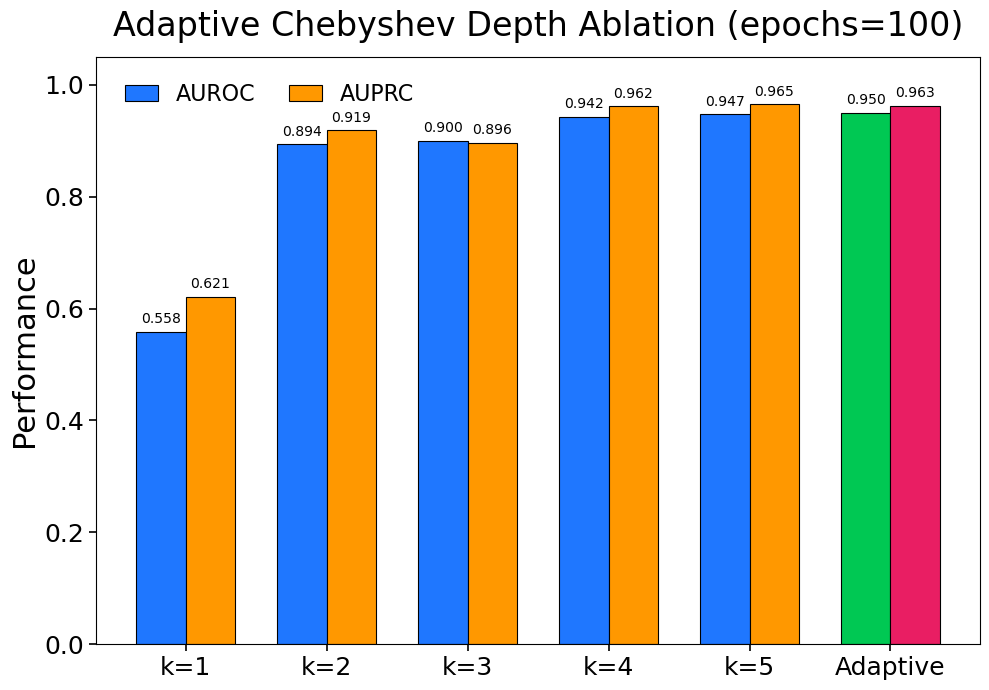

Saved: results/gene_prediction/ACGNN_depth_ablation.png


In [32]:
# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

x = np.arange(
    len(ablation_df)
)

width = 0.35

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

# ============================================================
# BRIGHT PUBLICATION COLORS
# ============================================================

colors_auc = [
    "#1F77FF",   # bright blue
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#00C853"    # bright green (Adaptive)
]

colors_aupr = [
    "#FF9800",   # bright orange
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#E91E63"    # bright magenta/red (Adaptive)
]

# ------------------------------------------------------------
# Bars
# ------------------------------------------------------------

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=colors_auc,
    edgecolor="black",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=colors_aupr,
    edgecolor="black",
    linewidth=0.8
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bar in bars1:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

for bar in bars2:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=22
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    f"Adaptive Chebyshev Depth Ablation (epochs={args.num_epochs})",
    fontsize=24,
    pad=15
)

ax.tick_params(
    axis="both",
    direction="out",
    length=5,
    width=1.2,
    labelsize=18
)

# ax.legend(
#     frameon=False,
#     fontsize=14,
#     loc="lower right"
# )

ax.legend(
    frameon=False,
    fontsize=16,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=2,
    handlelength=1.5,
    columnspacing=1.5
)

# # ------------------------------------------------------------
# # Grid
# # ------------------------------------------------------------

# ax.grid(
#     axis="y",
#     linestyle="--",
#     alpha=0.4
# )

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_depth_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)

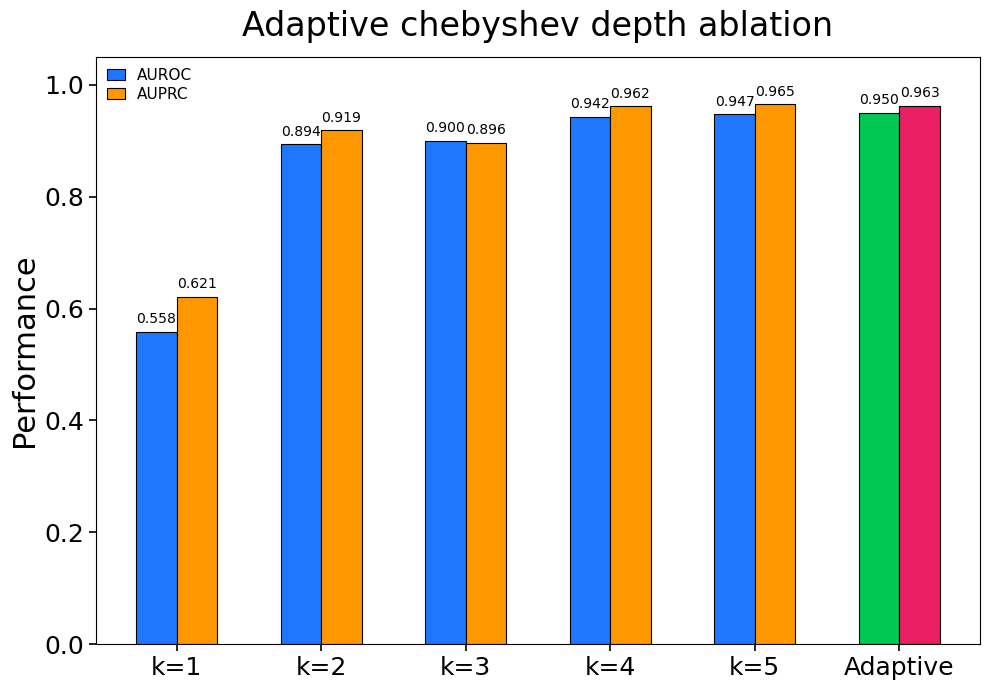

Saved: results/gene_prediction/ACGNN_depth_ablation.png


In [33]:
# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

x = np.arange(
    len(ablation_df)
)

width = 0.28

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

colors_auc = [
    "#1F77FF",   # bright blue
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#00C853"    # bright green (Adaptive)
]

colors_aupr = [
    "#FF9800",   # bright orange
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#E91E63"    # bright magenta/red (Adaptive)
]

# ------------------------------------------------------------
# Bars
# ------------------------------------------------------------

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=colors_auc,
    edgecolor="black",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=colors_aupr,
    edgecolor="black",
    linewidth=0.8
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bar in bars1:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

for bar in bars2:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=22
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    # f"Adaptive Chebyshev Depth Ablation (epochs={args.num_epochs})",
    f"Adaptive chebyshev depth ablation",
    fontsize=24,
    pad=15
)

ax.tick_params(
    axis="both",
    direction="out",
    length=5,
    width=1.2,
    labelsize=18
)

# ax.legend(
#     frameon=False,
#     fontsize=14,
#     loc="lower right"
# )

# ax.legend(
#     frameon=False,
#     fontsize=16,
#     loc="upper left",
#     bbox_to_anchor=(0.01, 0.99),
#     ncol=2,
#     handlelength=1.5,
#     columnspacing=1.5
# )
ax.legend(
    frameon=False,
    fontsize=11,
    loc="upper left",
    ncol=1,
    handlelength=1.2,
    labelspacing=0.3,
    borderpad=0.2
)

# # ------------------------------------------------------------
# # Grid
# # ------------------------------------------------------------

# ax.grid(
#     axis="y",
#     linestyle="--",
#     alpha=0.4
# )

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_depth_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)

Running baseline ACGNN...
Running ACGNN + GCL...


,Model,AUROC,AUPRC
0,ACGNN,0.954441,0.969532
1,ACGNN + GCL,0.938723,0.956757


Saved: results/gene_prediction/ACGNN_GCL_ablation.csv


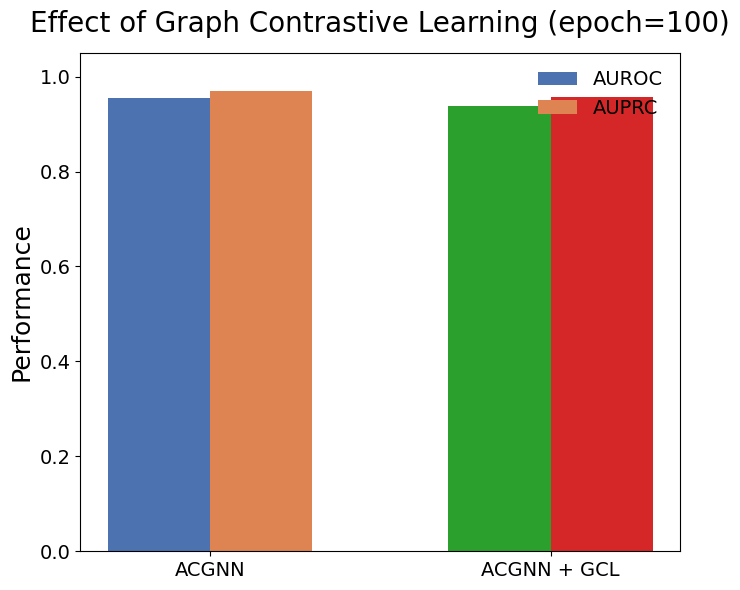

Saved: results/gene_prediction/ACGNN_GCL_ablation.png


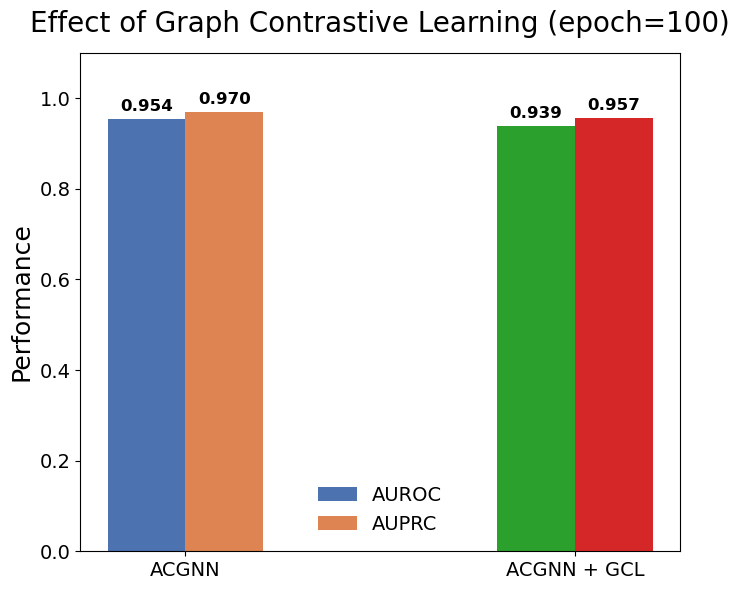

Saved: results/gene_prediction/ACGNN_GCL_ablation.png


In [34]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Linear
from dgl.nn import SAGEConv, GATConv, GraphConv, GINConv, ChebConv
from torch_geometric.utils import dropout_edge, negative_sampling, remove_self_loops, add_self_loops
import math
from torch.nn import Parameter
import dgl
import dgl.function as fn
from dgl.nn.pytorch.conv import ChebConv


class ACGNN(nn.Module):
    def __init__(
        self,
        in_feats,
        hidden_feats,
        out_feats,
        k=3,
        dropout=0.3,
        epsilon=1e-4
    ):
        super().__init__()

        # 🔹 SAVE ARCHITECTURE METADATA (for logging / CSV)
        self.in_feats = in_feats
        self.hidden_feats = hidden_feats
        self.out_feats = out_feats
        self.k = k
        self.dropout = dropout
        self.epsilon = epsilon

        # Chebyshev Convolution Layers
        self.cheb1 = ChebConv(in_feats, hidden_feats, k)
        self.cheb2 = ChebConv(hidden_feats, hidden_feats, k)
        self.cheb3 = ChebConv(hidden_feats, hidden_feats, k)

        # Fully Connected Layer (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Batch Normalization
        self.norm = nn.BatchNorm1d(hidden_feats)

        # Dropout
        self.dropout_layer = nn.Dropout(dropout)

    def forward(
        self,
        graph,
        features,
        lambda_max=None,
        return_embeddings=False
    ):
        if lambda_max is None:
            lambda_max = dgl.laplacian_lambda_max(graph)

        x = F.relu(
            self.cheb1(
                graph,
                features,
                lambda_max=lambda_max
            )
        )
        x = self.norm(x)

        prev_x = x.clone()

        for _ in range(1, self.k):

            x_new = F.relu(
                self.cheb2(
                    graph,
                    x,
                    lambda_max=lambda_max
                )
            )

            if torch.norm(x_new - prev_x) < self.epsilon:
                break

            prev_x = x_new.clone()
            x = x_new

        x_res = x

        x = F.relu(
            self.cheb3(
                graph,
                x,
                lambda_max=lambda_max
            )
        )

        x = self.dropout_layer(x) + x_res

        embeddings = x

        logits = self.mlp(embeddings)

        if return_embeddings:
            return logits, embeddings

        return logits
    
    def get_config(self):
        return {
            "in_feats": self.in_feats,
            "hidden_feats": self.hidden_feats,
            "out_feats": self.out_feats,
            # "num_layers": self.num_layers,
        }

# ============================================================
# ABLATION:
# EFFECT OF GRAPH CONTRASTIVE LEARNING (GCL)
# ============================================================

import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupervisedContrastiveLoss(torch.nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):

        device = embeddings.device

        embeddings = F.normalize(
            embeddings,
            p=2,
            dim=1
        )

        similarity = torch.matmul(
            embeddings,
            embeddings.T
        )

        similarity = (
            similarity / self.temperature
        )

        labels = labels.view(-1, 1)

        positive_mask = (
            labels == labels.T
        ).float().to(device)

        diag = torch.eye(
            labels.shape[0],
            device=device
        )

        positive_mask = (
            positive_mask - diag
        )

        exp_sim = torch.exp(similarity)

        denominator = (
            exp_sim * (1 - diag)
        ).sum(
            dim=1,
            keepdim=True
        )

        log_prob = (
            similarity
            -
            torch.log(
                denominator + 1e-8
            )
        )

        mean_log_prob_pos = (
            positive_mask * log_prob
        ).sum(dim=1)

        mean_log_prob_pos = (
            mean_log_prob_pos
            /
            (
                positive_mask.sum(dim=1)
                + 1e-8
            )
        )

        loss = -mean_log_prob_pos.mean()

        return loss


# ============================================================
# TRAIN + EVALUATE
# ============================================================

def run_model(
    use_contrastive=False,
    lambda_cl=0.1
):

    model = ACGNN(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=1,
        k=5,
        epsilon=1e-4
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    cls_loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    cl_loss_fn = (
        SupervisedContrastiveLoss(
            temperature=0.2
        )
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(
        args.num_epochs
    ):

        model.train()

        logits, embeddings = model(
            graph,
            features,
            return_embeddings=True
        )

        logits = logits.squeeze()

        cls_loss = cls_loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        if use_contrastive:

            cl_loss = cl_loss_fn(
                embeddings[train_mask],
                labels[train_mask]
            )

            loss = (
                cls_loss
                +
                lambda_cl * cl_loss
            )

        else:

            cl_loss = torch.tensor(
                0.0,
                device=device
            )

            loss = cls_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

    y_true = labels[
        test_mask
    ].cpu().numpy()

    y_score = probs[
        test_mask
    ].cpu().numpy()

    auc = roc_auc_score(
        y_true,
        y_score
    )

    aupr = average_precision_score(
        y_true,
        y_score
    )

    return auc, aupr


# ============================================================
# RUN ABLATION
# ============================================================

results = []

print("Running baseline ACGNN...")

auc, aupr = run_model(
    use_contrastive=False
)

results.append({

    "Model":
        "ACGNN",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

print("Running ACGNN + GCL...")

auc, aupr = run_model(
    use_contrastive=True,
    lambda_cl=0.1
)

results.append({

    "Model":
        "ACGNN + GCL",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

# ============================================================
# RESULTS TABLE
# ============================================================

ablation_df = pd.DataFrame(
    results
)

display(
    ablation_df
)

ablation_csv = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.csv"
)

ablation_df.to_csv(
    ablation_csv,
    index=False
)

print(
    f"Saved: {ablation_csv}"
)

# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7,6)
)

x = np.arange(
    len(ablation_df)
)

width = 0.30

ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    f"Effect of Graph Contrastive Learning (epoch={args.num_epochs})",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)


num_nodes = graph.num_nodes()

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

x = np.arange(
    len(ablation_df)
)

# smaller bars
width = 0.20

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

# ============================================================
# ADD SCORES ON TOP OF BARS
# ============================================================

for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.10
)

ax.set_title(
    "Effect of Graph Contrastive Learning (epoch=100)",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path}")

In [35]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================

import os
import time
import dgl
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# =========================================================
# RELATIONSHIP FILES relation_csv_path = (
# =========================================================

NETWORKS = {

    "Pathway": (
        "../../ASPIRE-GNN/process/data/processed/"
        "pathway_informed_gene_gene_pairs_omics_500.csv"
        # "../process/data/processed/"
        # "gene_pairs_limit5000.csv"
    ),

    # "CPDB": (
    #     "../process/data/"
    #     "CPDB_ppi_0.05_with_gene_type.csv"
    # ),

    # "HIPPIE": (
    #     "../process/data/"
    #     "hippie_high_confidence_human_with_gene_type_0.05.csv"
    # ),

    # "STRING": (
    #     "../process/data/"
    #     "STRING_ppi_950_with_gene_type_and_connected_driver_gene.csv"
    # )
}


# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n")
    print("="*60)
    print(network_name)
    print("="*60)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=
            source_csv_path,

        target_csv_path=
            target_csv_path,

        relation_csv_path=
            relation_file,

        max_edges_per_node=
            MAX_EDGES_PER_NODE
    )


    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = (
        embeddings_tensor
    )

    graph.ndata["label"] = (
        labels_tensor
    )

    train_mask = (
        labels_tensor != -1
    )

    graph.ndata[
        "train_mask"
    ] = train_mask

    graph = graph.to(device)

    features = (
        graph.ndata["feat"]
    )

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = (
        graph.ndata[
            "train_mask"
        ]
    )


    # =====================================================
    # MODEL
    # =====================================================

    in_feats = (
        features.shape[1]
    )

    model = choose_model(

        args.model_type,

        in_feats,

        args.hidden_feats,

        1

    ).to(device)


    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=args.learning_rate
    )


    loss_fn = FocalLoss(

        alpha=0.25,

        gamma=2
    )


    # =====================================================
    # TRAIN
    # =====================================================

    start = time.time()

    for epoch in range(
        args.num_epochs
    ):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(

            logits[
                train_mask
            ],

            labels[
                train_mask
            ]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        if epoch % 10 == 0:

            print(

                f"Epoch={epoch} "
                f"Loss={loss.item():.4f}"
            )

    train_time = (
        time.time() - start
    )


    # =====================================================
    # EVALUATION
    # =====================================================

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

        pred = (
            probs > 0.5
        ).float()


    y_true = (

        labels[
            train_mask
        ]
        .cpu()
        .numpy()
    )

    y_score = (

        probs[
            train_mask
        ]
        .cpu()
        .numpy()
    )

    y_pred = (

        pred[
            train_mask
        ]
        .cpu()
        .numpy()
    )


    # =====================================================
    # METRICS
    # =====================================================

    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "AUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time
    }

    return result


# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(

        relation_file,
        network_name
    )

    results.append(
        result
    )


# =========================================================
# SAVE RESULTS
# =========================================================

results_df = pd.DataFrame(
    results
)

print("\n")
print(results_df)

save_file = os.path.join(

    output_dir,

    "topology_ablation.csv"
)

results_df.to_csv(

    save_file,

    index=False
)



print(
    "\nSaved:",
    save_file
)



Pathway

[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/262345 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Epoch=0 Loss=0.0427
Epoch=10 Loss=0.0170
Epoch=20 Loss=0.0097
Epoch=30 Loss=0.0037
Epoch=40 Loss=0.0005
Epoch=50 Loss=0.0001
Epoch=60 Loss=0.0000
Epoch=70 Loss=0.0000
Epoch=80 Loss=0.0000
Epoch=90 Loss=0.0000


   Network  Nodes   Edges  AUROC  AUPRC   F1  Accuracy  TrainTime
0  Pathway   5563  138822    1.0    1.0  1.0       1.0  47.088093

Saved: results/gene_prediction/topology_ablation.csv


In [36]:
# =========================================================
# Split for each network
# =========================================================

from sklearn.model_selection import train_test_split

def build_masks(labels_tensor):

    labeled_idx = torch.where(
        labels_tensor != -1
    )[0]

    labeled_labels = labels_tensor[
        labeled_idx
    ].cpu().numpy()

    train_idx_np, temp_idx_np = train_test_split(
        labeled_idx.cpu().numpy(),
        test_size=0.40,
        stratify=labeled_labels,
        random_state=42
    )

    temp_labels = labels_tensor[
        temp_idx_np
    ].cpu().numpy()

    val_idx_np, test_idx_np = train_test_split(
        temp_idx_np,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )

    train_mask = torch.zeros(
        len(labels_tensor),
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        len(labels_tensor),
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        len(labels_tensor),
        dtype=torch.bool
    )

    train_mask[train_idx_np] = True
    val_mask[val_idx_np] = True
    test_mask[test_idx_np] = True

    return (
        train_mask,
        val_mask,
        test_mask
    )

In [37]:
# =========================================================
# LOAD FIXED NODE SET
# =========================================================

import torch
import numpy as np
from sklearn.model_selection import train_test_split

loaded_graph = torch.load(
    SAVE_GRAPH_PATH
)

nodes = loaded_graph["nodes"]

edges = loaded_graph["edges"]

embeddings_tensor = loaded_graph[
    "embeddings_tensor"
]

labels_tensor = loaded_graph[
    "labels_tensor"
]

print("Nodes:", len(nodes))
print("Features:", embeddings_tensor.shape)

# =========================================================
# GLOBAL TRAIN / VAL / TEST SPLIT
# =========================================================

labeled_idx = torch.where(
    labels_tensor != -1
)[0]

labeled_labels = labels_tensor[
    labeled_idx
].cpu().numpy()

train_idx_np, temp_idx_np = train_test_split(
    labeled_idx.cpu().numpy(),
    test_size=0.40,
    stratify=labeled_labels,
    random_state=42
)

temp_labels = labels_tensor[
    temp_idx_np
].cpu().numpy()

val_idx_np, test_idx_np = train_test_split(
    temp_idx_np,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

train_mask = torch.zeros(
    len(labels_tensor),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels_tensor),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(labels_tensor),
    dtype=torch.bool
)

train_mask[train_idx_np] = True
val_mask[val_idx_np] = True
test_mask[test_idx_np] = True

print(
    f"Train={train_mask.sum().item()} "
    f"Val={val_mask.sum().item()} "
    f"Test={test_mask.sum().item()}"
)

Nodes: 5563
Features: torch.Size([5563, 2688])
Train=559 Val=186 Test=187


In [38]:
# =========================================================
# LOAD EDGES
# =========================================================

import pandas as pd

def load_edge_list(
    relation_file,
    node_to_idx
):

    df = pd.read_csv(
        relation_file
    )

    src = []
    dst = []

    for _, row in df.iterrows():

        g1 = row.iloc[0]
        g2 = row.iloc[1]

        if (
            g1 in node_to_idx
            and
            g2 in node_to_idx
        ):

            src.append(
                node_to_idx[g1]
            )

            dst.append(
                node_to_idx[g2]
            )

    return (
        np.array(src),
        np.array(dst)
    )

In [39]:
# =========================================================
# TRAIN 
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score
)

def train_one_network(
    relation_file,
    network_name
):

    print("\n")
    print("="*60)
    print(network_name)
    print("="*60)

    node_to_idx = {

        node:i

        for i,node in enumerate(nodes)
    }

    src, dst = load_edge_list(
        relation_file,
        node_to_idx
    )

    graph = dgl.graph(
        (src,dst),
        num_nodes=len(nodes)
    )

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = (
        embeddings_tensor
    )

    graph.ndata["label"] = (
        labels_tensor
    )

    graph.ndata["train_mask"] = (
        train_mask
    )

    graph.ndata["val_mask"] = (
        val_mask
    )

    graph.ndata["test_mask"] = (
        test_mask
    )

    graph = graph.to(device)

    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    # =====================================================
    # MODEL
    # =====================================================

    model = choose_model(
        args.model_type,
        embeddings_tensor.shape[1],
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    best_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    # =====================================================
    # TRAIN
    # =====================================================

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[
                train_mask.to(device)
            ],
            labels[
                train_mask.to(device)
            ]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------
        # validation
        # ------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        print(
            "NaN logits:",
            torch.isnan(logits).sum().item()
        )

        print(
            "NaN probs:",
            torch.isnan(val_probs).sum().item()
        )

        print(
            "NaN features:",
            torch.isnan(features).sum().item()
        )

        print(
            "NaN labels:",
            torch.isnan(labels).sum().item()
        )



        val_auc = roc_auc_score(
            labels[
                val_mask.to(device)
            ].cpu().numpy(),

            val_probs[
                val_mask.to(device)
            ].cpu().numpy()
        )

        if val_auc > best_auc:

            best_auc = val_auc

            best_state = model.state_dict()

            counter = 0

        else:

            counter += 1

        if counter >= patience:

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # TEST
    # =====================================================

    model.load_state_dict(
        best_state
    )

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = labels[
        test_mask.to(device)
    ].cpu().numpy()

    y_score = probs[
        test_mask.to(device)
    ].cpu().numpy()

    y_pred = (
        y_score > 0.5
    ).astype(int)

    return {

        "Network":
        network_name,

        "Nodes":
        graph.number_of_nodes(),

        "Edges":
        graph.number_of_edges(),

        "AvgDegree":
        graph.in_degrees()
        .float()
        .mean()
        .item(),

        "Density":
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2),

        "ValAUROC":
        best_auc,

        "TestAUROC":
        roc_auc_score(
            y_true,
            y_score
        ),

        "TestAUPRC":
        average_precision_score(
            y_true,
            y_score
        ),

        "F1":
        f1_score(
            y_true,
            y_pred
        ),

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "TrainTime":
        train_time
    }

In [40]:
# =========================================================
# COMMON NODE SET
# =========================================================

common_nodes = None

network_nodes = {}

for network_name, relation_file in NETWORKS.items():

    (
        nodes,
        edges,
        embeddings,
        labels
    ) = load_graph_data_directly(
        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    if isinstance(nodes, dict):
        node_names = set(nodes.keys())
    else:
        node_names = set(nodes)

    network_nodes[network_name] = node_names

    if common_nodes is None:
        common_nodes = node_names
    else:
        common_nodes = (
            common_nodes &
            node_names
        )

print(
    "Common genes:",
    len(common_nodes)
)

# =========================================================
# GLOBAL SPLIT
# =========================================================

(
    nodes,
    edges,
    embeddings,
    labels
) = load_graph_data_directly(
    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

if isinstance(nodes, dict):
    node_names = list(nodes.keys())
else:
    node_names = list(nodes)

node_to_idx = {
    n:i
    for i,n in enumerate(node_names)
}

common_idx = np.array([
    node_to_idx[g]
    for g in common_nodes
    if g in node_to_idx
])

common_labels = labels[
    common_idx
]

labeled_mask = (
    common_labels != -1
)

labeled_idx = common_idx[
    labeled_mask.cpu().numpy()
]

labeled_labels = labels[
    labeled_idx
].cpu().numpy()

train_idx_np, temp_idx_np = train_test_split(
    labeled_idx,
    test_size=0.40,
    stratify=labeled_labels,
    random_state=42
)

temp_labels = labels[
    temp_idx_np
].cpu().numpy()

val_idx_np, test_idx_np = train_test_split(
    temp_idx_np,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

GLOBAL_TRAIN_GENES = set(
    train_idx_np.tolist()
)

GLOBAL_VAL_GENES = set(
    val_idx_np.tolist()
)

GLOBAL_TEST_GENES = set(
    test_idx_np.tolist()
)

print(
    len(GLOBAL_TRAIN_GENES),
    len(GLOBAL_VAL_GENES),
    len(GLOBAL_TEST_GENES)
)




[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/262345 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
559 186 187


In [41]:
# ============================================================
# BUILD STRING GENE NETWORK FOR ASPIRE-GNN
# KEEP ALL STRING EDGES
# DRIVER = 1, ALL OTHERS = 0
# ============================================================

import pandas as pd
import networkx as nx

# ============================================================
# INPUT FILES
# ============================================================

STRING_LINKS = (
    "../../ASPIRE-GNN/data/string/9606.protein.links.v12.0.txt.gz"
)

STRING_INFO = (
    "../../ASPIRE-GNN/data/string/9606.protein.info.v12.0.txt.gz"
)

DRIVER_FILE = (
    "../../ASPIRE-GNN/data/processed/763_driver_genes.txt"
)

NONDRIVER_FILE = (
    "../../ASPIRE-GNN/data/processed/5263_non_driver_genes.txt"
)
OUTPUT_NETWORK = (
    "../../ASPIRE-GNN/data/processed/STRING_gene_network.csv"
)

OUTPUT_NODES = (
    "../../ASPIRE-GNN/data/processed/STRING_node_labels.csv"
)

LINK_FILE = "../../ASPIRE-GNN/data/string/9606.protein.links.v12.0.txt.gz"
INFO_FILE = "../../ASPIRE-GNN/data/string/9606.protein.info.v12.0.txt.gz"

MIN_SCORE = 700

# MIN_SCORE = 400

# ============================================================
# LOAD DRIVER GENES
# ============================================================

drivers = set(
    pd.read_table(
        DRIVER_FILE,
        header=None
    )[0]
    .astype(str)
    .str.upper()
)

print(
    f"Driver genes: {len(drivers)}"
)

# ============================================================
# LOAD STRING INFO
# ============================================================

print("\nLoading STRING info...")

info_df = pd.read_csv(
    STRING_INFO,
    sep="\t"
)

print(
    "Protein info shape:",
    info_df.shape
)

id_to_gene = dict(
    zip(
        info_df["#string_protein_id"],
        info_df["preferred_name"]
    )
)

# ============================================================
# LOAD STRING LINKS
# ============================================================

print("\nLoading STRING links...")

links_df = pd.read_csv(
    STRING_LINKS,
    sep=" "
)

print(
    "Raw STRING links:",
    links_df.shape
)

# ============================================================
# HIGH-CONFIDENCE FILTER
# ============================================================

links_df = links_df[
    links_df["combined_score"] >= MIN_SCORE
]

print(
    "Edges after score filter:",
    len(links_df)
)

# ============================================================
# MAP PROTEIN IDS -> GENE SYMBOLS
# ============================================================

links_df["Gene1"] = (
    links_df["protein1"]
    .map(id_to_gene)
)

links_df["Gene2"] = (
    links_df["protein2"]
    .map(id_to_gene)
)

links_df = links_df.dropna(
    subset=["Gene1", "Gene2"]
)

links_df["Gene1"] = (
    links_df["Gene1"]
    .astype(str)
    .str.upper()
)

links_df["Gene2"] = (
    links_df["Gene2"]
    .astype(str)
    .str.upper()
)

links_df = links_df[
    links_df["Gene1"] != links_df["Gene2"]
]

print(
    "Mapped interactions:",
    len(links_df)
)

# ============================================================
# REMOVE DUPLICATE GENE PAIRS
# KEEP HIGHEST SCORE
# ============================================================

links_df["pair"] = links_df.apply(
    lambda r: tuple(
        sorted(
            [r["Gene1"], r["Gene2"]]
        )
    ),
    axis=1
)

links_df = (
    links_df
    .sort_values(
        "combined_score",
        ascending=False
    )
    # .drop_duplicates(
    #     subset="pair"
    # )
)

print(
    "Unique gene-gene interactions:",
    len(links_df)
)

# ============================================================
# BUILD GRAPH
# ============================================================

print("\nBuilding graph...")

G = nx.Graph()

for _, row in links_df.iterrows():

    # G.add_edge(
    #     row["Gene1"],
    #     row["Gene2"],
    #     weight=row["combined_score"]
    # )
    if G.has_edge(
        row["Gene1"],
        row["Gene2"]
    ):

        G[row["Gene1"]][row["Gene2"]]["weight"] += (
            row["combined_score"]
        )

    else:

        G.add_edge(
            row["Gene1"],
            row["Gene2"],
            weight=row["combined_score"]
        )


print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

# # ============================================================
# # OPTIONAL:
# # KEEP LARGEST CONNECTED COMPONENT
# # ============================================================

# largest_cc = max(
#     nx.connected_components(G),
#     key=len
# )

# G = G.subgraph(
#     largest_cc
# ).copy()

# print(
#     "\nLargest CC Nodes:",
#     G.number_of_nodes()
# )

# print(
#     "Largest CC Edges:",
#     G.number_of_edges()
# )


# ============================================================
# EDGE FILE
# gene_type = 1 if either endpoint is a driver
# ============================================================

edge_rows = []

for u, v, data in G.edges(data=True):

    edge_label = int(
        (u in drivers) or
        (v in drivers)
    )

    edge_rows.append({

        "Gene1": u,

        "Gene2": v,

        "gene_type": edge_label,

        "weight": data.get(
            "weight",
            1
        )
    })

edge_df = pd.DataFrame(
    edge_rows
)

print(
    "\nEdge table shape:"
)

print(
    edge_df.shape
)

print(
    edge_df.head()
)

print(
    "\nPositive edges:",
    edge_df["gene_type"].sum()
)

print(
    "Negative edges:",
    len(edge_df)
    -
    edge_df["gene_type"].sum()
)

# ============================================================
# SAVE EDGE FILE
# ============================================================

edge_df.to_csv(
    OUTPUT_NETWORK,
    index=False
)

print(
    "\nSaved edge file:"
)

print(
    OUTPUT_NETWORK
)

# ============================================================
# NODE LABEL FILE
# ============================================================

node_rows = []

for gene in sorted(
    G.nodes()
):

    node_rows.append({

        "Gene": gene,

        "gene_type":
            int(gene in drivers)

    })

node_df = pd.DataFrame(
    node_rows
)

node_df.to_csv(
    OUTPUT_NODES,
    index=False
)

print(
    "\nSaved node file:"
)

print(
    OUTPUT_NODES
)

# ============================================================
# SUMMARY
# ============================================================

num_drivers = (
    node_df["gene_type"]
    .sum()
)

num_non_drivers = (
    len(node_df)
    -
    num_drivers
)

print("\n===================================")

print(
    "STRING Network Summary"
)

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

print(
    "Driver nodes:",
    num_drivers
)

print(
    "Other nodes:",
    num_non_drivers
)

print(
    "Driver ratio:",
    round(
        num_drivers / len(node_df),
        4
    )
)

Driver genes: 763

Loading STRING info...
Protein info shape: (19699, 4)

Loading STRING links...
Raw STRING links: (13715404, 3)
Edges after score filter: 473860
Mapped interactions: 473860
Unique gene-gene interactions: 473860

Building graph...
Nodes: 16201
Edges: 236930

Edge table shape:
(236930, 4)
   Gene1     Gene2  gene_type  weight
0  IFT57     IFT80          0    1998
1  IFT57    IFT172          0    1998
2  IFT57  TRAF3IP1          0    1998
3  IFT57     IFT52          0    1998
4  IFT57     IFT81          0    1998

Positive edges: 42017
Negative edges: 194913

Saved edge file:
../../ASPIRE-GNN/data/processed/STRING_gene_network.csv

Saved node file:
../../ASPIRE-GNN/data/processed/STRING_node_labels.csv

STRING Network Summary
Nodes: 16201
Edges: 236930
Driver nodes: 735
Other nodes: 15466
Driver ratio: 0.0454



[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=398 Val=117 Test=128
Epoch=0 Loss=0.0426 ValAUROC=0.9153
Epoch=10 Loss=0.0159 ValAUROC=0.9225
Epoch=20 Loss=0.0036 ValAUROC=0.9340
Epoch=30 Loss=0.0002 ValAUROC=0.9131
Early stopping at epoch 34


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5563  138822  24.954521  0.004486  0.936488    0.94011   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.894246  0.807692   0.84375  24.487124  

Saved: results/gene_prediction/topology_ablation.csv


,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5563,138822,24.954521,0.004486,0.936488,0.94011,0.894246,0.807692,0.84375,24.487124


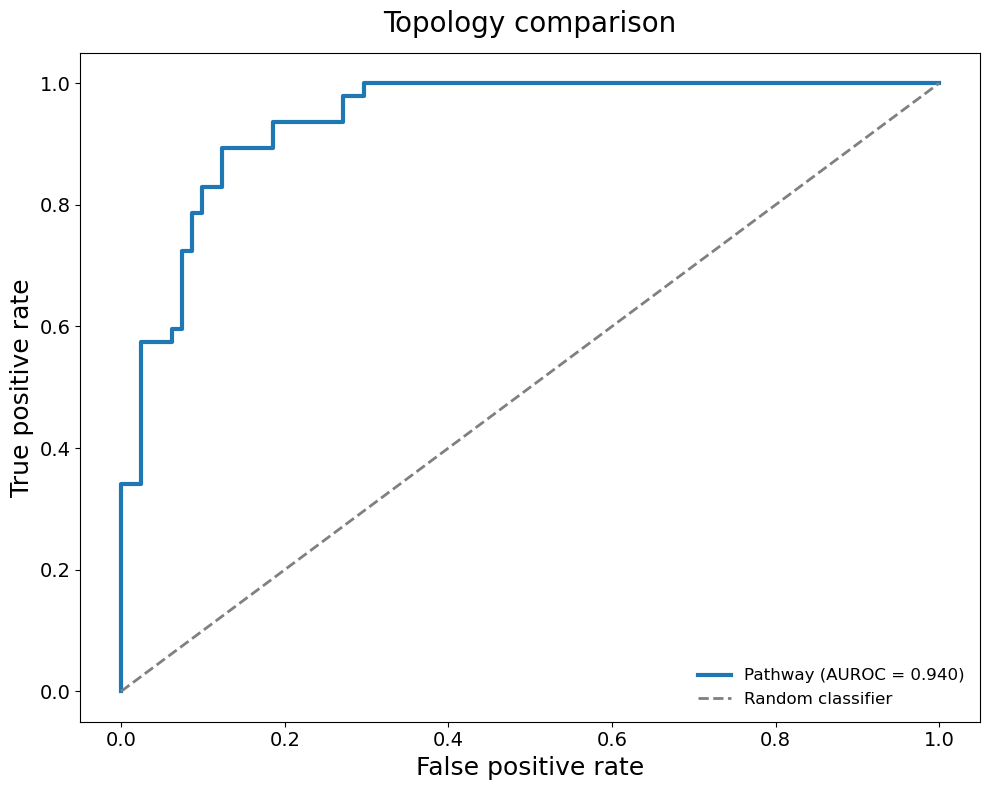

Saved ROC curve: results/gene_prediction/topology_ablation_ROC.png


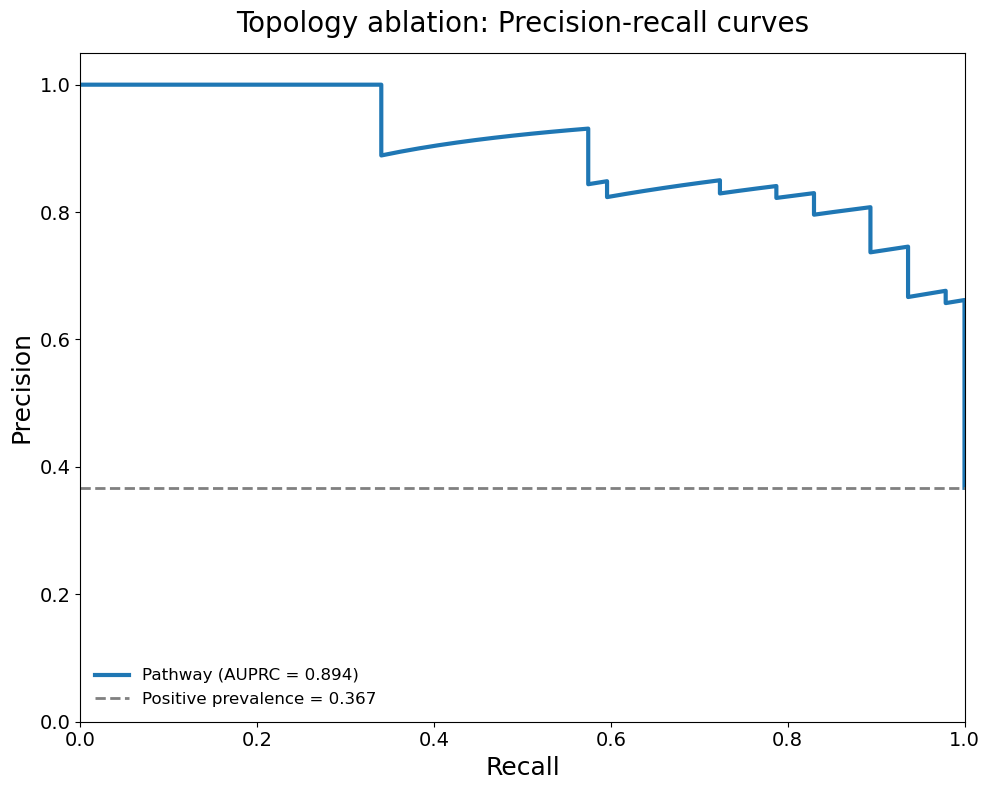

Saved precision-recall curve: results/gene_prediction/topology_ablation_PR.png


,Network,Test_AUROC,Test_AUPRC,Test_PositiveRate,TestSamples
0,Pathway,0.94011,0.894246,0.367188,128


Saved curve metrics: results/gene_prediction/topology_ablation_curve_metrics.csv
Saved: results/gene_prediction/topology_ablation_ROC.png


In [42]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)


# =========================================================
# GLOBAL GENE UNIVERSE:
# Pathway genes as reference
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

# labeled genes only
labeled_mask=(pathway_labels!=-1)

pathway_genes=pathway_gene_names[
    labeled_mask.cpu().numpy()
]

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "Pathway labeled genes:",
    len(pathway_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        pathway_genes,
        test_size=0.40,
        stratify=pathway_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)


# =========================================================
# NETWORK-SPECIFIC TRAINING EPOCHS
# =========================================================

NETWORK_EPOCHS = {
    "Pathway": args.num_epochs,
    "STRING": args.num_epochs,
}

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(200):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )


results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# TEST ROC + PRECISION-RECALL CURVES
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


NETWORK_COLORS = {
    "ACGNN": "#2ca02c",
    "STRING": "#9467bd"
}
# =========================================================
# VALIDATE STORED TEST OUTPUTS
# =========================================================

valid_results = []

for r in results:

    y_true = np.asarray(r["y_true"]).astype(int)
    y_score = np.asarray(r["y_score"]).astype(float)

    # Remove NaN or infinite scores before plotting
    valid_mask = (
        np.isfinite(y_true) &
        np.isfinite(y_score)
    )

    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    # ROC and PR curves require both classes in the test split
    if len(np.unique(y_true)) < 2:
        print(
            f"[WARNING] Skipping {r['Network']}: "
            "test set contains only one class."
        )
        continue

    valid_results.append({
        "Network": r["Network"],
        "y_true": y_true,
        "y_score": y_score
    })

if len(valid_results) == 0:
    raise ValueError(
        "No valid networks available for ROC/PR plotting. "
        "Check that each test split contains both positive and negative labels."
    )

# =========================================================
# ROC CURVE
# =========================================================

plt.figure(figsize=(10, 8))

for r in valid_results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        color=NETWORK_COLORS.get(
            r["Network"],
            None
        ),
        label=(
            f"{r['Network']} "
            f"(AUROC = {roc_auc:.3f})"
        )
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=2,
    label="Random classifier"
)

plt.xlabel(
    "False positive rate",
    fontsize=18
)

plt.ylabel(
    "True positive rate",
    fontsize=18
)

plt.title(
    # "Topology ablation: ROC curves",
    "Topology comparison",
    fontsize=20,
    pad=15
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(
    fontsize=12,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved ROC curve:", roc_file)

# =========================================================
# PRECISION-RECALL CURVE
# =========================================================

plt.figure(figsize=(10, 8))

for r in valid_results:

    precision, recall, _ = precision_recall_curve(
        r["y_true"],
        r["y_score"]
    )

    auprc = average_precision_score(
        r["y_true"],
        r["y_score"]
    )

    plt.plot(
        recall,
        precision,
        linewidth=3,
        color=NETWORK_COLORS.get(
            r["Network"],
            None
        ),
        label=(
            f"{r['Network']} "
            f"(AUPRC = {auprc:.3f})"
        )
    )

# Positive-class prevalence baseline
all_y_true = np.concatenate([
    r["y_true"]
    for r in valid_results
])

positive_rate = np.mean(all_y_true)

plt.axhline(
    y=positive_rate,
    linestyle="--",
    color="gray",
    linewidth=2,
    label=(
        f"Positive prevalence = "
        f"{positive_rate:.3f}"
    )
)

plt.xlabel(
    "Recall",
    fontsize=18
)

plt.ylabel(
    "Precision",
    fontsize=18
)

plt.title(
    # "Topology Ablation: Precision-Recall Curves",
    "Topology ablation: Precision-recall curves",
    fontsize=20,
    pad=15
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(
    fontsize=12,
    frameon=False,
    loc="lower left"
)

plt.tight_layout()

pr_file = os.path.join(
    output_dir,
    "topology_ablation_PR.png"
)

plt.savefig(
    pr_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved precision-recall curve:", pr_file)

# =========================================================
# CURVE METRICS TABLE
# =========================================================

curve_metrics = []

for r in valid_results:

    curve_metrics.append({
        "Network": r["Network"],
        "Test_AUROC": roc_auc_score(
            r["y_true"],
            r["y_score"]
        ),
        "Test_AUPRC": average_precision_score(
            r["y_true"],
            r["y_score"]
        ),
        "Test_PositiveRate": np.mean(
            r["y_true"]
        ),
        "TestSamples": len(
            r["y_true"]
        )
    })

curve_metrics_df = pd.DataFrame(
    curve_metrics
).sort_values(
    "Test_AUROC",
    ascending=False
)

display(curve_metrics_df)

curve_metrics_file = os.path.join(
    output_dir,
    "topology_ablation_curve_metrics.csv"
)

curve_metrics_df.to_csv(
    curve_metrics_file,
    index=False
)

print("Saved curve metrics:", curve_metrics_file)


print(
    "Saved:",
    roc_file
)


Saved threshold sensitivity table: results/gene_prediction/topology_ablation_threshold_sensitivity.csv


,Network,Threshold,Precision,Recall,Sensitivity,Specificity,F1,Accuracy,BalancedAccuracy,MCC,TP,TN,FP,FN,PredictedPositive,PredictedNegative
0,Pathway,0.05,0.534091,1.0,1.0,0.493827,0.696296,0.679688,0.746914,0.513565,47,40,41,0,88,40
1,Pathway,0.06,0.540230,1.0,1.0,0.506173,0.701493,0.687500,0.753086,0.522924,47,41,40,0,87,41
2,Pathway,0.07,0.559524,1.0,1.0,0.543210,0.717557,0.710938,0.771605,0.551307,47,44,37,0,84,44
3,Pathway,0.08,0.573171,1.0,1.0,0.567901,0.728682,0.726562,0.783951,0.570530,47,46,35,0,82,46
4,Pathway,0.09,0.594937,1.0,1.0,0.604938,0.746032,0.750000,0.802469,0.599917,47,49,32,0,79,49



Best F1 threshold per network:


,Network,Threshold,F1,Precision,Recall,Specificity,BalancedAccuracy,MCC,TP,TN,FP,FN
0,Pathway,0.66,0.848485,0.807692,0.893617,0.876543,0.88508,0.7559,42,71,10,5



Saved best thresholds: results/gene_prediction/topology_ablation_best_thresholds.csv


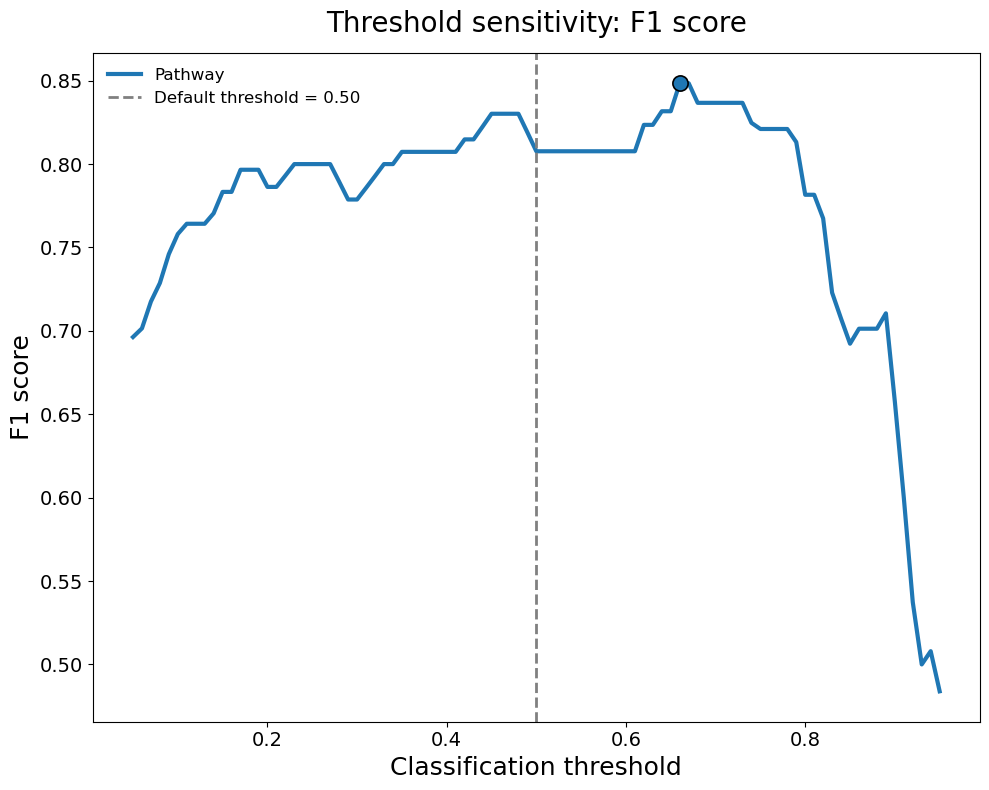

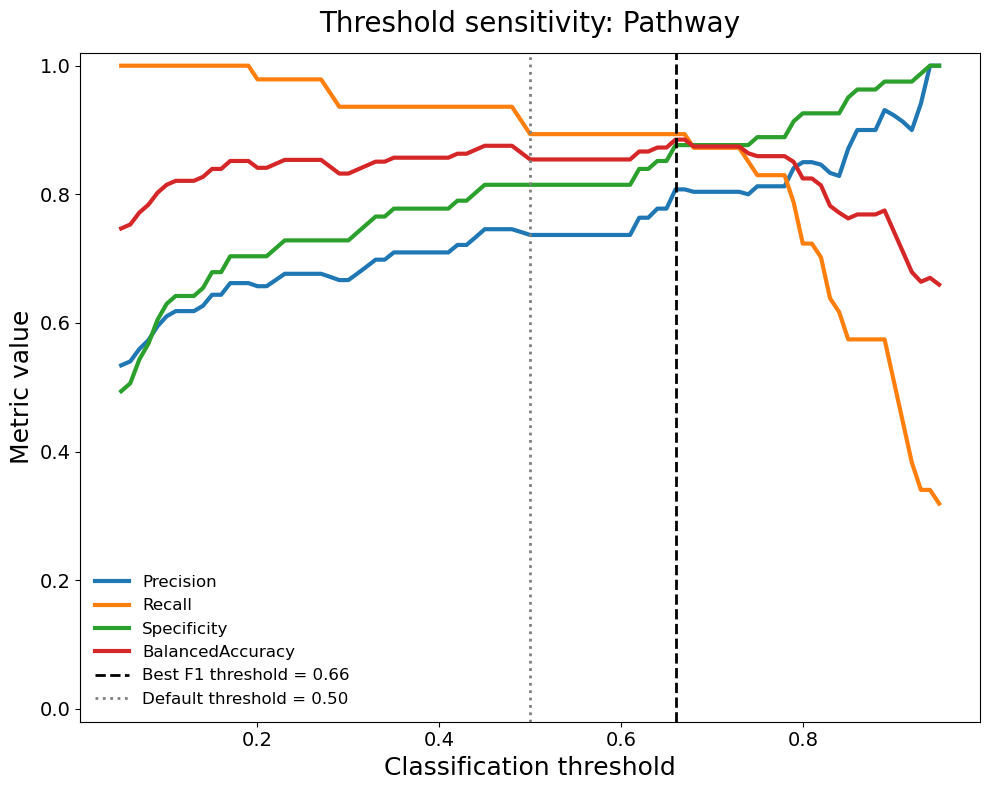

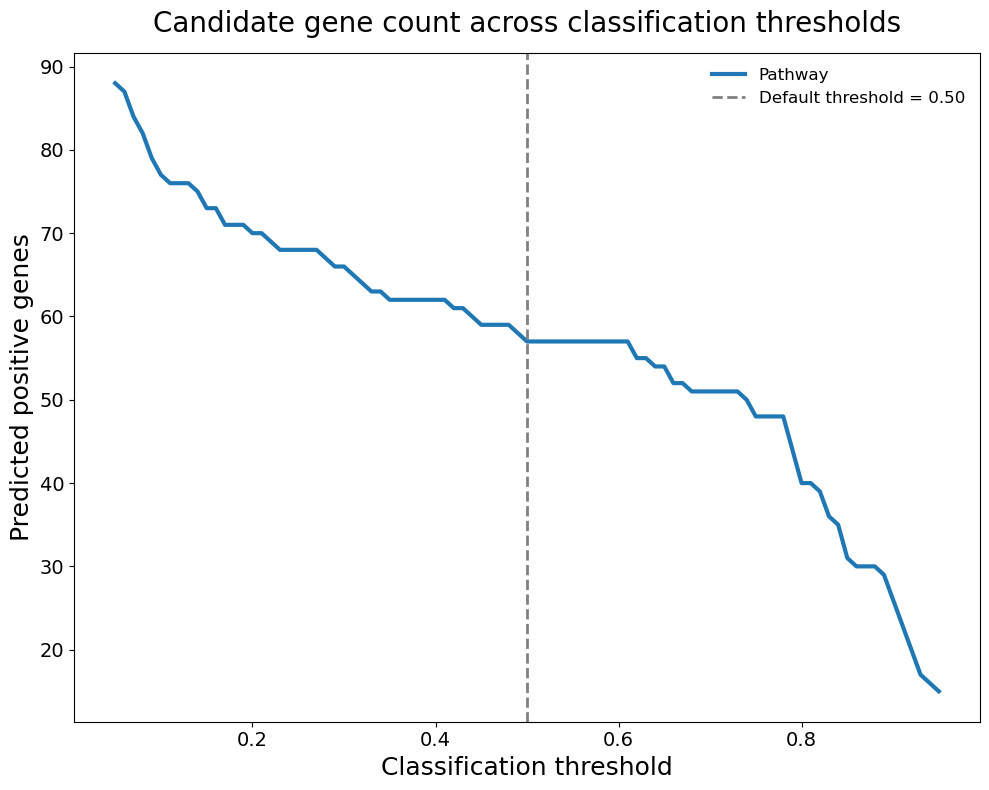


Saved threshold sensitivity plots:
 - results/gene_prediction/topology_ablation_threshold_F1.png
 - results/gene_prediction/topology_ablation_predicted_positive_count.png


In [43]:
# =========================================================
# THRESHOLD SENSITIVITY ANALYSIS
# =========================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix
)

# ---------------------------------------------------------
# Threshold grid
# ---------------------------------------------------------

thresholds = np.round(
    np.arange(0.05, 0.96, 0.01),
    2
)

threshold_results = []

# =========================================================
# COMPUTE METRICS ACROSS THRESHOLDS
# =========================================================

for r in valid_results:

    network_name = r["Network"]

    y_true = np.asarray(
        r["y_true"]
    ).astype(int)

    y_score = np.asarray(
        r["y_score"]
    ).astype(float)

    for threshold in thresholds:

        y_pred = (
            y_score >= threshold
        ).astype(int)

        # Confusion matrix with fixed binary labels
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        balanced_acc = balanced_accuracy_score(
            y_true,
            y_pred
        )

        # MCC may fail or be uninformative for one predicted class
        try:
            mcc = matthews_corrcoef(
                y_true,
                y_pred
            )
        except Exception:
            mcc = np.nan

        threshold_results.append({

            "Network": network_name,

            "Threshold": threshold,

            "Precision": precision,

            "Recall": recall,

            "Sensitivity": sensitivity,

            "Specificity": specificity,

            "F1": f1,

            "Accuracy": accuracy,

            "BalancedAccuracy": balanced_acc,

            "MCC": mcc,

            "TP": tp,

            "TN": tn,

            "FP": fp,

            "FN": fn,

            "PredictedPositive": int(
                y_pred.sum()
            ),

            "PredictedNegative": int(
                (y_pred == 0).sum()
            )
        })

# =========================================================
# SAVE THRESHOLD RESULTS
# =========================================================

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_csv_file = os.path.join(
    output_dir,
    "topology_ablation_threshold_sensitivity.csv"
)

threshold_df.to_csv(
    threshold_csv_file,
    index=False
)

print(
    "\nSaved threshold sensitivity table:",
    threshold_csv_file
)

display(
    threshold_df.head()
)

# =========================================================
# IDENTIFY BEST THRESHOLD PER NETWORK
# =========================================================

best_threshold_df = (
    threshold_df
    .sort_values(
        ["Network", "F1"],
        ascending=[True, False]
    )
    .groupby(
        "Network",
        as_index=False
    )
    .first()
)

best_threshold_df = best_threshold_df[
    [
        "Network",
        "Threshold",
        "F1",
        "Precision",
        "Recall",
        "Specificity",
        "BalancedAccuracy",
        "MCC",
        "TP",
        "TN",
        "FP",
        "FN"
    ]
]

best_threshold_file = os.path.join(
    output_dir,
    "topology_ablation_best_thresholds.csv"
)

best_threshold_df.to_csv(
    best_threshold_file,
    index=False
)

print(
    "\nBest F1 threshold per network:"
)

display(
    best_threshold_df
)

print(
    "\nSaved best thresholds:",
    best_threshold_file
)

# =========================================================
# PLOT: F1 SCORE VS THRESHOLD
# =========================================================

plt.figure(
    figsize=(10, 8)
)

for network_name in threshold_df["Network"].unique():

    network_df = threshold_df[
        threshold_df["Network"] == network_name
    ]

    plt.plot(
        network_df["Threshold"],
        network_df["F1"],
        linewidth=3,
        color=NETWORK_COLORS.get(
            network_name,
            None
        ),
        label=network_name
    )

    best_row = best_threshold_df[
        best_threshold_df["Network"] == network_name
    ].iloc[0]

    plt.scatter(
        best_row["Threshold"],
        best_row["F1"],
        s=120,
        color=NETWORK_COLORS.get(
            network_name,
            None
        ),
        edgecolor="black",
        linewidth=1.2,
        zorder=5
    )

plt.axvline(
    x=0.50,
    linestyle="--",
    color="gray",
    linewidth=2,
    label="Default threshold = 0.50"
)

plt.xlabel(
    "Classification threshold",
    fontsize=18
)

plt.ylabel(
    "F1 score",
    fontsize=18
)

plt.title(
    "Threshold sensitivity: F1 score",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()

f1_threshold_file = os.path.join(
    output_dir,
    "topology_ablation_threshold_F1.png"
)

plt.savefig(
    f1_threshold_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# PLOT: PRECISION / RECALL / SPECIFICITY VS THRESHOLD
# =========================================================

metrics_to_plot = [
    "Precision",
    "Recall",
    "Specificity",
    "BalancedAccuracy"
]

for network_name in threshold_df["Network"].unique():

    network_df = threshold_df[
        threshold_df["Network"] == network_name
    ]

    plt.figure(
        figsize=(10, 8)
    )

    for metric_name in metrics_to_plot:

        plt.plot(
            network_df["Threshold"],
            network_df[metric_name],
            linewidth=3,
            label=metric_name
        )

    best_row = best_threshold_df[
        best_threshold_df["Network"] == network_name
    ].iloc[0]

    plt.axvline(
        x=best_row["Threshold"],
        linestyle="--",
        color="black",
        linewidth=2,
        label=(
            f"Best F1 threshold = "
            f"{best_row['Threshold']:.2f}"
        )
    )

    plt.axvline(
        x=0.50,
        linestyle=":",
        color="gray",
        linewidth=2,
        label="Default threshold = 0.50"
    )

    plt.xlabel(
        "Classification threshold",
        fontsize=18
    )

    plt.ylabel(
        "Metric value",
        fontsize=18
    )

    plt.title(
        f"Threshold sensitivity: {network_name}",
        fontsize=20,
        pad=15
    )

    plt.xticks(
        fontsize=14
    )

    plt.yticks(
        fontsize=14
    )

    plt.ylim(
        -0.02,
        1.02
    )

    plt.legend(
        fontsize=12,
        frameon=False,
        loc="best"
    )

    plt.tight_layout()

    safe_network_name = (
        network_name
        .replace(" ", "_")
        .replace("/", "_")
    )

    metric_file = os.path.join(
        output_dir,
        f"threshold_sensitivity_{safe_network_name}.png"
    )

    plt.savefig(
        metric_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# =========================================================
# PLOT: NUMBER OF PREDICTED POSITIVE GENES VS THRESHOLD
# =========================================================

plt.figure(
    figsize=(10, 8)
)

for network_name in threshold_df["Network"].unique():

    network_df = threshold_df[
        threshold_df["Network"] == network_name
    ]

    plt.plot(
        network_df["Threshold"],
        network_df["PredictedPositive"],
        linewidth=3,
        color=NETWORK_COLORS.get(
            network_name,
            None
        ),
        label=network_name
    )

plt.axvline(
    x=0.50,
    linestyle="--",
    color="gray",
    linewidth=2,
    label="Default threshold = 0.50"
)

plt.xlabel(
    "Classification threshold",
    fontsize=18
)

plt.ylabel(
    "Predicted positive genes",
    fontsize=18
)

plt.title(
    "Candidate gene count across classification thresholds",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()

candidate_count_file = os.path.join(
    output_dir,
    "topology_ablation_predicted_positive_count.png"
)

plt.savefig(
    candidate_count_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved threshold sensitivity plots:")
print(" -", f1_threshold_file)
print(" -", candidate_count_file)

In [44]:
num_nodes = graph.num_nodes()

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

In [45]:
# # ============================================================
# # HYPERPARAMETER SEARCH
# # Validation-set selection only
# # ============================================================

# import os
# import copy
# import random
# import itertools
# import numpy as np
# import pandas as pd
# import torch

# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score
# )

# # ============================================================
# # REPRODUCIBILITY
# # ============================================================

# def set_seed(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)

#     if torch.cuda.is_available():
#         torch.cuda.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)

#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False


# # ============================================================
# # SAFE METRIC FUNCTION
# # ============================================================

# def safe_binary_metrics_(y_true, y_score):

#     y_true = np.asarray(y_true).astype(int)
#     y_score = np.asarray(y_score).astype(float)

#     valid_mask = np.isfinite(y_true) & np.isfinite(y_score)

#     y_true = y_true[valid_mask]
#     y_score = y_score[valid_mask]

#     if len(y_true) == 0:
#         return {
#             "AUROC": np.nan,
#             "AUPRC": np.nan
#         }

#     if len(np.unique(y_true)) < 2:
#         return {
#             "AUROC": np.nan,
#             "AUPRC": np.nan
#         }

#     return {
#         "AUROC": roc_auc_score(y_true, y_score),
#         "AUPRC": average_precision_score(y_true, y_score)
#     }


# def safe_binary_metrics(y_true, y_score):

#     # -------------------------
#     # flatten
#     # -------------------------
#     y_true=np.asarray(
#         y_true
#     ).reshape(-1)

#     y_score=np.asarray(
#         y_score
#     ).reshape(-1)

#     # -------------------------
#     # remove invalid
#     # -------------------------
#     valid_mask=(
#         np.isfinite(y_true)
#         &
#         np.isfinite(y_score)
#     )

#     y_true=y_true[valid_mask]
#     y_score=y_score[valid_mask]

#     # -------------------------
#     # remove unlabeled nodes
#     # -------------------------
#     keep=(y_true!=-1)

#     y_true=y_true[keep]
#     y_score=y_score[keep]

#     # -------------------------
#     # force binary labels
#     # -------------------------
#     y_true=(y_true>0).astype(int)

#     # -------------------------
#     # debug
#     # -------------------------
#     print(
#         "unique labels:",
#         np.unique(y_true)
#     )

#     # -------------------------
#     # safety
#     # -------------------------
#     if len(y_true)==0:

#         return {
#             "AUROC":np.nan,
#             "AUPRC":np.nan
#         }

#     if len(np.unique(y_true))<2:

#         return {
#             "AUROC":np.nan,
#             "AUPRC":np.nan
#         }

#     try:

#         auc=roc_auc_score(
#             y_true,
#             y_score
#         )

#         auprc=average_precision_score(
#             y_true,
#             y_score
#         )

#     except Exception as e:

#         print(e)

#         auc=np.nan
#         auprc=np.nan

#     return {

#         "AUROC":auc,
#         "AUPRC":auprc
#     }

# # ============================================================
# # TRAIN ONE CONFIGURATION
# # ============================================================

# def train_one_config(
#     graph,
#     features,
#     labels,
#     train_mask,
#     val_mask,
#     config,
#     seed=42,
#     max_epochs=300,
#     patience=30
# ):

#     set_seed(seed)

#     graph = graph.to(device)
#     features = features.to(device)
#     labels = labels.to(device)

#     num_nodes = min(
#         graph.number_of_nodes(),
#         len(features),
#         len(labels),
#         len(train_mask),
#         len(val_mask)
#     )

#     features = features[:num_nodes]
#     labels = labels[:num_nodes]

#     train_mask = train_mask[:num_nodes]
#     val_mask = val_mask[:num_nodes]

#     if graph.number_of_nodes()!=num_nodes:
#         graph = dgl.node_subgraph(
#             graph,
#             torch.arange(num_nodes)
#         )

        
#     train_mask = train_mask.to(device)
#     val_mask = val_mask.to(device)

#     model = ACGNN(
#         in_feats=features.shape[1],
#         hidden_feats=config["hidden_feats"],
#         out_feats=1,
#         k=config["k"],
#         dropout=config["dropout"],
#         epsilon=config["epsilon"]
#     ).to(device)

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=config["learning_rate"],
#         weight_decay=config["weight_decay"]
#     )

#     loss_fn = FocalLoss(
#         alpha=config["focal_alpha"],
#         gamma=config["focal_gamma"]
#     )

#     best_val_auprc = -np.inf
#     best_val_auc = np.nan
#     best_epoch = 0
#     best_state = None
#     early_stop_counter = 0

#     for epoch in range(max_epochs):

#         model.train()

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         loss = loss_fn(
#             logits[train_mask],
#             labels[train_mask]
#         )

#         optimizer.zero_grad()
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(
#             model.parameters(),
#             max_norm=5.0
#         )

#         optimizer.step()

#         model.eval()

#         with torch.no_grad():

#             val_logits = model(
#                 graph,
#                 features
#             ).squeeze()

#             val_probs = torch.sigmoid(
#                 val_logits
#             )

#         val_y_true = labels[
#             val_mask
#         ].detach().cpu().numpy()

#         val_y_score = val_probs[
#             val_mask
#         ].detach().cpu().numpy()

#         val_metrics = safe_binary_metrics(
#             val_y_true,
#             val_y_score
#         )

#         val_auc = val_metrics["AUROC"]
#         val_auprc = val_metrics["AUPRC"]

#         if np.isnan(val_auprc):
#             continue

#         if val_auprc > best_val_auprc:

#             best_val_auprc = val_auprc
#             best_val_auc = val_auc
#             best_epoch = epoch + 1

#             best_state = copy.deepcopy(
#                 model.state_dict()
#             )

#             early_stop_counter = 0

#         else:
#             early_stop_counter += 1

#         if early_stop_counter >= patience:
#             break

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     return {
#         "ValAUROC": best_val_auc,
#         "ValAUPRC": best_val_auprc,
#         "BestEpoch": best_epoch
#     }


# # ============================================================
# # SEARCH SPACE
# # ============================================================

# SEARCH_SPACE = {
#     "hidden_feats": [64, 128, 256],
#     "k": [1, 2, 3, 5],
#     "dropout": [0.1, 0.3, 0.5],
#     "epsilon": [1e-3, 1e-4],
#     "learning_rate": [3e-4, 1e-3],
#     "weight_decay": [0.0, 1e-5, 1e-4],
#     "focal_alpha": [0.25],
#     "focal_gamma": [2.0]
# }

# SEEDS = [42, 52, 62]

# MAX_EPOCHS = 300
# PATIENCE = 30

# # ============================================================
# # CREATE CONFIGURATIONS
# # ============================================================

# keys = list(SEARCH_SPACE.keys())

# configs = [
#     dict(zip(keys, values))
#     for values in itertools.product(
#         *[SEARCH_SPACE[key] for key in keys]
#     )
# ]

# print(f"Total hyperparameter configurations: {len(configs)}")
# print(f"Seeds per configuration: {len(SEEDS)}")
# print(f"Total training runs: {len(configs) * len(SEEDS)}")

# # ============================================================
# # RUN SEARCH
# # ============================================================

# search_results = []

# for config_id, config in enumerate(configs):

#     print(
#         f"\nConfiguration "
#         f"{config_id + 1}/{len(configs)}"
#     )

#     print(config)

#     config_runs = []

#     for seed in SEEDS:

#         run_result = train_one_config(
#             graph=graph,
#             features=features,
#             labels=labels,
#             train_mask=train_mask,
#             val_mask=val_mask,
#             config=config,
#             seed=seed,
#             max_epochs=MAX_EPOCHS,
#             patience=PATIENCE
#         )

#         run_result["seed"] = seed

#         config_runs.append(
#             run_result
#         )

#         print(
#             f"Seed={seed} | "
#             f"ValAUROC={run_result['ValAUROC']:.4f} | "
#             f"ValAUPRC={run_result['ValAUPRC']:.4f} | "
#             f"Epoch={run_result['BestEpoch']}"
#         )

#     val_auc_values = [
#         r["ValAUROC"]
#         for r in config_runs
#     ]

#     val_auprc_values = [
#         r["ValAUPRC"]
#         for r in config_runs
#     ]

#     epoch_values = [
#         r["BestEpoch"]
#         for r in config_runs
#     ]

#     row = {
#         **config,

#         "MeanValAUROC":
#             np.nanmean(val_auc_values),

#         "StdValAUROC":
#             np.nanstd(val_auc_values),

#         "MeanValAUPRC":
#             np.nanmean(val_auprc_values),

#         "StdValAUPRC":
#             np.nanstd(val_auprc_values),

#         "MeanBestEpoch":
#             np.mean(epoch_values),

#         "Seeds":
#             ",".join(map(str, SEEDS))
#     }

#     search_results.append(row)

# # ============================================================
# # RESULTS TABLE
# # ============================================================

# hyperparam_df = pd.DataFrame(
#     search_results
# )

# hyperparam_df = hyperparam_df.sort_values(
#     by=[
#         "MeanValAUPRC",
#         "MeanValAUROC"
#     ],
#     ascending=False
# ).reset_index(
#     drop=True
# )

# display(
#     hyperparam_df.head(20)
# )

# # ============================================================
# # SAVE RESULTS
# # ============================================================

# os.makedirs(output_dir, exist_ok=True)

# hyperparam_file = os.path.join(
#     output_dir,
#     "ACGNN_hyperparameter_search.csv"
# )

# hyperparam_df.to_csv(
#     hyperparam_file,
#     index=False
# )

# print(
#     "\nSaved hyperparameter search:",
#     hyperparam_file
# )

# # ============================================================
# # BEST CONFIGURATION
# # ============================================================

# best_config = hyperparam_df.iloc[0].to_dict()

# print("\nBest configuration:")
# for key, value in best_config.items():
#     print(f"{key}: {value}")

In [46]:
# # ============================================================
# # SAVE TOP RESULTS TO LATEX TABLE
# # ============================================================

# top_n = 20

# latex_df = (
#     hyperparam_df
#     .head(top_n)
#     .copy()
# )

# # round numbers
# for col in [
#     "MeanValAUROC",
#     "StdValAUROC",
#     "MeanValAUPRC",
#     "StdValAUPRC",
#     "MeanBestEpoch"
# ]:
#     latex_df[col] = latex_df[col].round(4)

# # optional: rename columns
# latex_df = latex_df.rename(
#     columns={
#         "hidden_feats": "Hidden",
#         "k": "k",
#         "dropout": "Dropout",
#         "epsilon": "Epsilon",
#         "learning_rate": "LR",
#         "weight_decay": "WeightDecay",
#         "focal_alpha": "Alpha",
#         "focal_gamma": "Gamma",
#         "MeanValAUROC": "AUROC",
#         "MeanValAUPRC": "AUPRC",
#         "MeanBestEpoch": "Epoch"
#     }
# )

# latex_table = latex_df.to_latex(
#     index=False,
#     escape=False,
#     float_format="%.4f",
#     column_format="cccccccccccc",
#     caption=(
#         "Top hyperparameter configurations for ACGNN "
#         "ranked by validation AUPRC."
#     ),
#     label="tab:acgnn_hyperparameter_search"
# )

# latex_file = os.path.join(
#     output_dir,
#     "ACGNN_hyperparameter_search.tex"
# )

# with open(latex_file, "w") as f:
#     f.write(latex_table)

# print(f"Saved LaTeX table: {latex_file}")


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=398 Val=117 Test=128
Epoch=0 Loss=0.0411 ValAUROC=0.9116
Epoch=10 Loss=0.0144 ValAUROC=0.9187
Epoch=20 Loss=0.0034 ValAUROC=0.9237
Epoch=30 Loss=0.0001 ValAUROC=0.9066
Early stopping at epoch 34


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5563  138822  24.954521  0.004486  0.933064   0.943262   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.905042  0.803738  0.835938  25.039657  

Saved: results/gene_prediction/topology_ablation.csv


,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5563,138822,24.954521,0.004486,0.933064,0.943262,0.905042,0.803738,0.835938,25.039657


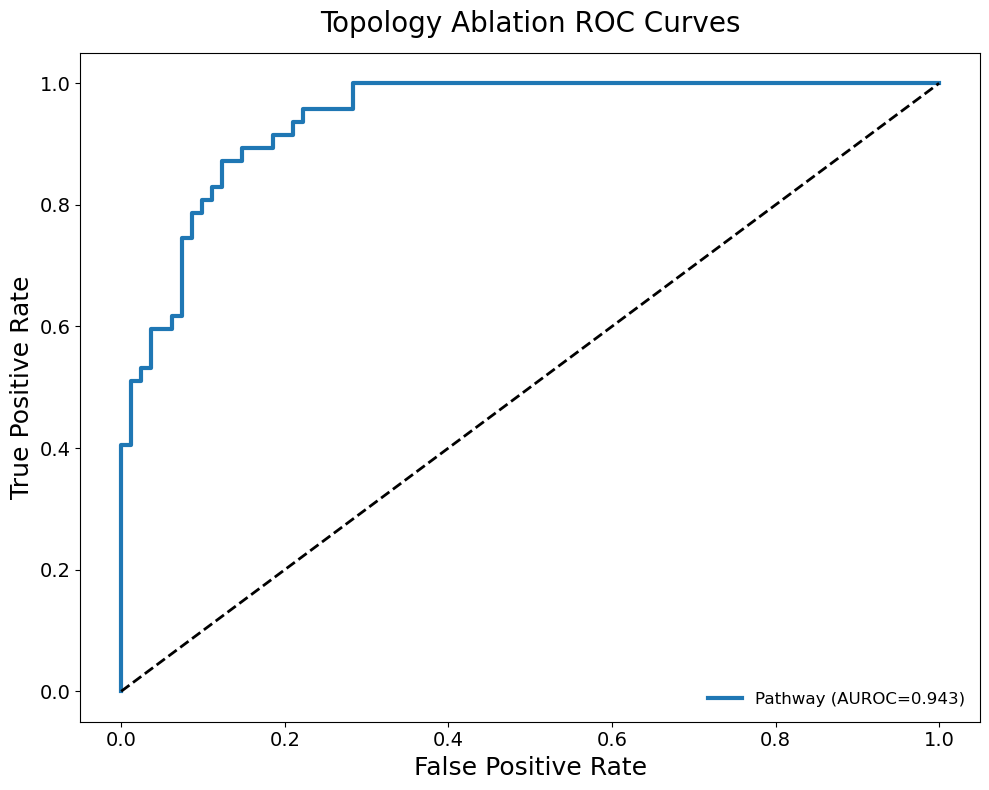

Saved: results/gene_prediction/topology_ablation_ROC.png


In [47]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# # =========================================================
# # NETWORK FILES
# # =========================================================

# NETWORKS = {

#     "Pathway":
#         "../process/data/processed/gene_pairs_limit5000.csv",

#     # "CPDB":
#     #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

#     # "HIPPIE":
#     #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

#     "STRING":
#         "../data/processed/STRING_gene_network.csv"
# }

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

# labeled genes only
labeled_mask=(pathway_labels!=-1)

pathway_genes=pathway_gene_names[
    labeled_mask.cpu().numpy()
]

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "Pathway labeled genes:",
    len(pathway_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        pathway_genes,
        test_size=0.40,
        stratify=pathway_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)


# =========================================================
# NETWORK-SPECIFIC TRAINING EPOCHS
# =========================================================

NETWORK_EPOCHS = {
    "Pathway": args.num_epochs,
    # "CPDB": args.num_epochs * 1,   # double epochs for CPDB
    # "HIPPIE": args.num_epochs,
    "STRING": args.num_epochs,
}

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name,
    num_epochs=None
):

    if num_epochs is None:
        num_epochs = args.num_epochs

    print(f"\nTraining {network_name} for {num_epochs} epochs")
    

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    # for epoch in range(300):
    # for epoch in range(args.num_epochs):
    for epoch in range(num_epochs):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

# results = []

# for network_name, relation_file in NETWORKS.items():

#     result = train_one_network(
#         relation_file,
#         network_name
#     )

#     results.append(
#         result
#     )

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file=relation_file,
        network_name=network_name,
        num_epochs=NETWORK_EPOCHS[network_name]
    )

    results.append(result)

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

print(
    "Saved:",
    roc_file
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=398 Val=117 Test=128
Epoch=0 Loss=0.0441 ValAUROC=0.9166
Epoch=10 Loss=0.0174 ValAUROC=0.9225
Epoch=20 Loss=0.0054 ValAUROC=0.9315
Epoch=30 Loss=0.0005 ValAUROC=0.9013
Early stopping at epoch 38


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5563  138822  24.954521  0.004486    0.9368   0.938797   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.894769  0.803738  0.835938  28.161134  

Saved: results/gene_prediction/topology_ablation.csv


,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5563,138822,24.954521,0.004486,0.9368,0.938797,0.894769,0.803738,0.835938,28.161134


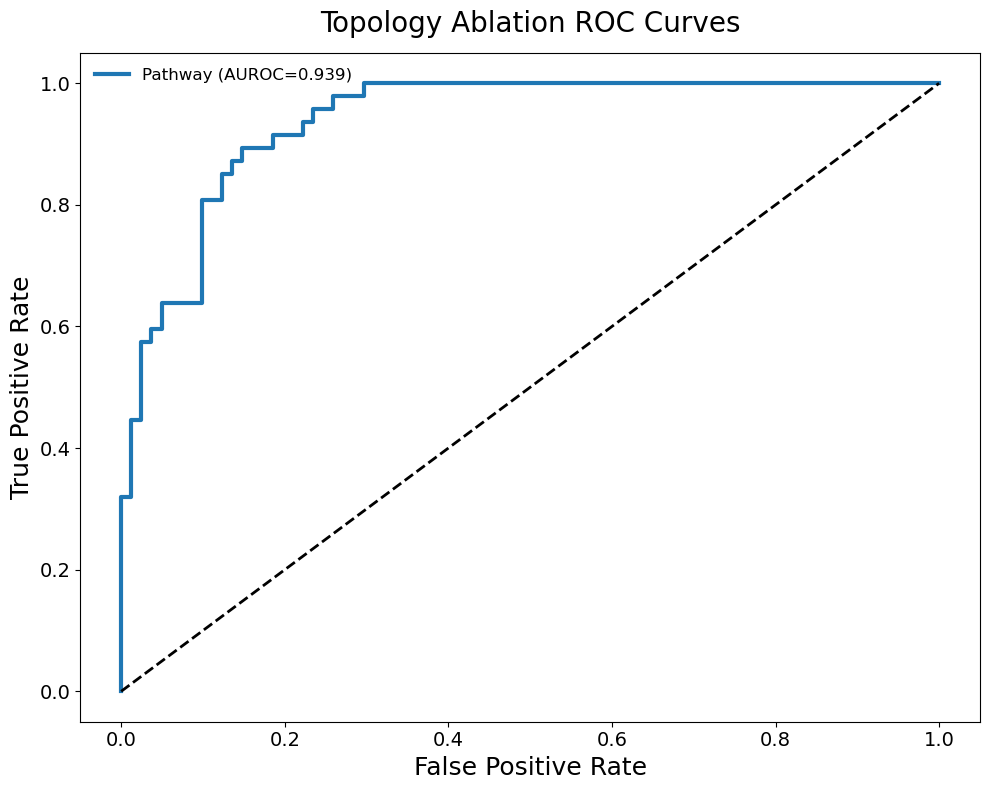

Saved: results/gene_prediction/topology_ablation_ROC.png


In [48]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# # =========================================================
# # NETWORK FILES
# # =========================================================

# NETWORKS = {

#     "Pathway":
#         "../process/data/processed/gene_pairs_limit5000.csv",

#     # "CPDB":
#     #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

#     # "HIPPIE":
#     #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

#     "STRING":
#         "../data/processed/STRING_gene_network.csv"
# }

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

# labeled genes only
labeled_mask=(pathway_labels!=-1)

pathway_genes=pathway_gene_names[
    labeled_mask.cpu().numpy()
]

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "Pathway labeled genes:",
    len(pathway_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        pathway_genes,
        test_size=0.40,
        stratify=pathway_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)



# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18 
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...


[INFO] Skipped edges: 258144

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5809
Edges: 232294
Embedding tensor shape: torch.Size([5809, 2688])
Labels tensor shape: torch.Size([5809])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
[INFO] Loading graph: ../../ACGNN_data/data/multiomics_meth/Pathway_omics_ppi_embeddings_graph_2048.json


Processing graph entries: 100%|██████████| 9524/9524 [00:00<00:00, 474064.27it/s]


[INFO] Converting to tensors...
[INFO] Nodes: 2184
[INFO] Edges: 9524
Train=2457 Val=819 Test=820

Pathway
Train=2457 Val=819 Test=820
Epoch=0 Loss=0.0431 ValAUROC=0.7964
Epoch=10 Loss=0.0203 ValAUROC=0.8877
Epoch=20 Loss=0.0139 ValAUROC=0.9335
Epoch=30 Loss=0.0093 ValAUROC=0.9372
Epoch=40 Loss=0.0051 ValAUROC=0.9346
Early stopping: 44

CPDB
Train=73 Val=21 Test=27
Epoch=0 Loss=0.0463 ValAUROC=0.8667
Epoch=10 Loss=0.0139 ValAUROC=0.8889
Epoch=20 Loss=0.0124 ValAUROC=0.7556
Epoch=30 Loss=0.0109 ValAUROC=0.7667
Epoch=40 Loss=0.0085 ValAUROC=0.7778
Early stopping: 47


   Network  Nodes   Edges  TrainNodes  ValNodes  TestNodes  BestValAUROC  \
0  Pathway   5809  238103        2457       819        820      0.944379   
1     CPDB   2184   11708          73        21         27      0.933333   

      AUROC     AUPRC        F1  Accuracy  TrainTime  \
0  0.938169  0.951589  0.864929  0.860976  45.675618   
1  0.739130  0.951616  0.920000  0.851852  15.274371   

                             

,Network,Nodes,Edges,TrainNodes,ValNodes,TestNodes,BestValAUROC,AUROC,AUPRC,F1,Accuracy,TrainTime,y_pred,test_node_indices
0,Pathway,5809,238103,2457,819,820,0.944379,0.938169,0.951589,0.864929,0.860976,45.675618,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, ...","[2, 49, 53, 56, 60, 67, 74, 75, 77, 81, 104, 1..."
1,CPDB,2184,11708,73,21,27,0.933333,0.739130,0.951616,0.920000,0.851852,15.274371,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[98, 100, 116, 179, 336, 345, 357, 589, 628, 6..."


Saved: results/gene_prediction/Pathway_vs_CPDB.tex


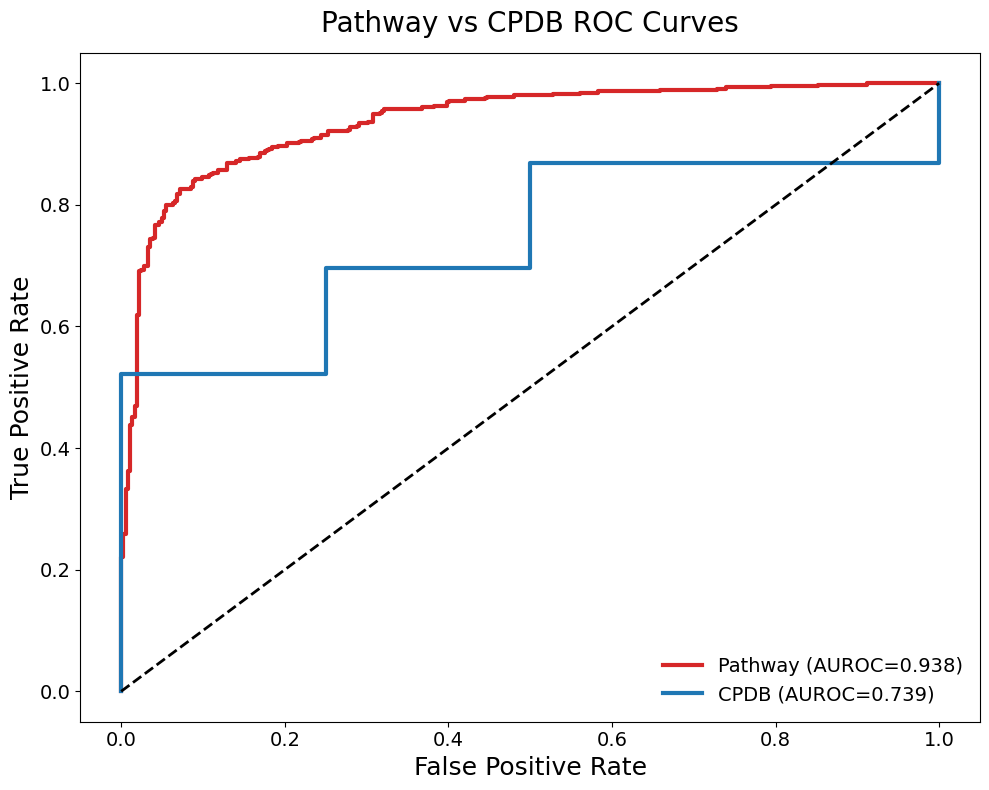

Saved: results/gene_prediction/Pathway_vs_CPDB_ROC.png


In [49]:
# =========================================================
# TOPOLOGY ABLATION
# Pathway vs CPDB topology
# =========================================================

import os
import time
import copy 
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

# =========================================================
# PATHWAY GRAPH
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,

    relation_csv_path=
    "../../ASPIRE-GNN/process/data/processed/gene_pairs_limit5000.csv",

    max_edges_per_node=
    MAX_EDGES_PER_NODE
)

# =========================================================
# CPDB GRAPH
# =========================================================

data_path=os.path.join(

    "../../ACGNN_data/data/multiomics_meth/",
    f"{args.net_type}_omics_ppi_embeddings_graph_2048.json"
)

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
)=load_graph_data(
    data_path
)

# =========================================================
# GLOBAL SPLIT:
# USE PATHWAY GENES
# =========================================================

pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

labeled_mask=(
    pathway_labels!=-1
)

pathway_genes=(
    pathway_gene_names[
        labeled_mask.cpu().numpy()
    ]
)

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

train_genes,temp_genes=(
    train_test_split(

        pathway_genes,

        test_size=0.4,

        stratify=
        pathway_gene_labels,

        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(

        temp_genes,

        test_size=0.5,

        stratify=temp_labels,

        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)



# =========================================================
# TRAIN FUNCTION
# =========================================================

# =========================================================
# TRAIN FUNCTION
# works on already-loaded graphs
# =========================================================

def train_one_graph(
    nodes,
    edges,
    embeddings_tensor,
    labels_tensor,
    network_name
):

    print("\n"+"="*70)
    print(network_name)
    print("="*70)

    # =====================================================
    # GRAPH
    # =====================================================

    graph=dgl.graph(edges)

    graph=dgl.add_self_loop(graph)

    graph.ndata["feat"]=embeddings_tensor
    graph.ndata["label"]=labels_tensor


    # =====================================================
    # BUILD MASKS USING GENE NAMES
    # =====================================================

    num_nodes=graph.number_of_nodes()

    train_mask=torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask=torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask=torch.zeros(
        num_nodes,
        dtype=torch.bool
    )


    # ---------------------------------------
    # Gene -> node index mapping
    # ---------------------------------------

    if isinstance(nodes,dict):

        node_map=nodes

    else:

        node_map={
            g:i
            for i,g in enumerate(nodes)
        }


    # ---------------------------------------
    # assign masks only for genes existing
    # in current graph
    # ---------------------------------------

    train_valid=[
        node_map[g]
        for g in train_genes
        if g in node_map
    ]

    val_valid=[
        node_map[g]
        for g in val_genes
        if g in node_map
    ]

    test_valid=[
        node_map[g]
        for g in test_genes
        if g in node_map
    ]


    train_mask[train_valid]=True
    val_mask[val_valid]=True
    test_mask[test_valid]=True


    # remove unlabeled nodes

    labeled_mask=(
        labels_tensor!=-1
    )

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask


    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )


    graph.ndata["train_mask"]=train_mask
    graph.ndata["val_mask"]=val_mask
    graph.ndata["test_mask"]=test_mask

    graph=graph.to(device)

    features=graph.ndata["feat"]

    labels=(
        graph.ndata["label"]
        .float()
    )

    # =====================================================
    # MODEL
    # =====================================================

    in_feats=features.shape[1]

    model=choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)


    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn=FocalLoss(
        alpha=0.25,
        gamma=2
    )


    # =====================================================
    # TRAIN
    # =====================================================

    num_epochs=600 if network_name=="CPDB" else 300

    patience=40 if network_name=="CPDB" else 20

    best_auc=0
    best_state=None
    counter=0

    start=time.time()

    for epoch in range(num_epochs):

        model.train()

        logits=model(
            graph,
            features
        ).squeeze()

        loss=loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        # -----------------------------
        # validation
        # -----------------------------

        model.eval()

        with torch.no_grad():

            probs=torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )


        val_auc=roc_auc_score(

            labels[val_mask]
            .cpu()
            .numpy(),

            probs[val_mask]
            .cpu()
            .numpy()
        )


        if val_auc>best_auc:

            best_auc=val_auc

            best_state=copy.deepcopy(
                model.state_dict()
            )

            counter=0

        else:

            counter+=1


        if epoch%10==0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )


        if counter>=patience:

            print(
                f"Early stopping: {epoch}"
            )

            break


    train_time=time.time()-start


    # =====================================================
    # TEST
    # =====================================================

    model.load_state_dict(
        best_state
    )

    model.eval()

    with torch.no_grad():

        probs=torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )


    y_true=(
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score=(
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred=(
        y_score>0.5
    ).astype(int)




    # =====================================================
    # RESULTS
    # =====================================================

    result = {

        # ---------------------------------------------
        # Network metadata
        # ---------------------------------------------
        "Network": network_name,

        "Nodes": graph.number_of_nodes(),

        "Edges": graph.number_of_edges(),

        "TrainNodes": int(train_mask.sum().item()),

        "ValNodes": int(val_mask.sum().item()),

        "TestNodes": int(test_mask.sum().item()),

        # ---------------------------------------------
        # Validation performance
        # ---------------------------------------------
        "BestValAUROC": float(best_auc),

        # ---------------------------------------------
        # Test performance
        # ---------------------------------------------
        "AUROC": float(
            roc_auc_score(
                y_true,
                y_score
            )
        ),

        "AUPRC": float(
            average_precision_score(
                y_true,
                y_score
            )
        ),

        "F1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "Accuracy": float(
            accuracy_score(
                y_true,
                y_pred
            )
        ),

        "TrainTime": float(train_time),

        # ---------------------------------------------
        # Keep raw test outputs for ROC / PR curves
        # ---------------------------------------------
        "y_true": y_true,

        "y_score": y_score,

        "y_pred": y_pred,

        # Optional: retain test-node identities
        "test_node_indices": torch.where(
            test_mask
        )[0].detach().cpu().numpy()
    }

    return result



# =========================================================
# RUN ABLATION
# =========================================================

# =========================================================
# RUN COMPARISON
# =========================================================

results=[]

# -----------------------------
# Pathway
# -----------------------------

result_pathway=(
    train_one_graph(

        pathway_nodes,
        pathway_edges,
        pathway_embeddings,
        pathway_labels,

        "Pathway"
    )
)

results.append(
    result_pathway
)


# -----------------------------
# CPDB
# -----------------------------

result_cpdb=(
    train_one_graph(

        cpdb_nodes,
        cpdb_edges,
        cpdb_embeddings,
        cpdb_labels,

        "CPDB"
    )
)

results.append(
    result_cpdb)


# =========================================================
# SAVE RESULTS TABLE
# =========================================================

results_df=pd.DataFrame([

    {
        k:v
        for k,v in r.items()
        if k not in [
            "y_true",
            "y_score"
        ]
    }

    for r in results
])

results_df=results_df.sort_values(
    "AUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file=os.path.join(

    output_dir,
    "Pathway_vs_CPDB.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(
    results_df
)


# =========================================================
# SAVE LATEX TABLE
# =========================================================

latex_file=os.path.join(

    output_dir,
    "Pathway_vs_CPDB.tex"
)

latex_table=results_df.to_latex(

    index=False,

    float_format=
    "%.4f",

    caption=(
        "Comparison of "
        "pathway-informed topology "
        "and CPDB PPI topology."
    ),

    label=
    "tab:pathway_cpdb",

    escape=False
)

with open(
    latex_file,
    "w"
) as f:

    f.write(
        latex_table
    )

print(
    "Saved:",
    latex_file
)


# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

colors={

    "Pathway":"#d62728",
    "CPDB":"#1f77b4"
}


for r in results:

    fpr,tpr,_=roc_curve(

        r["y_true"],
        r["y_score"]
    )

    roc_auc=auc(
        fpr,
        tpr
    )

    plt.plot(

        fpr,
        tpr,

        linewidth=3,

        color=colors[
            r["Network"]
        ],

        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )


# diagonal

plt.plot(

    [0,1],
    [0,1],

    linestyle="--",

    color="black",

    linewidth=2
)


plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(

    "Pathway vs CPDB ROC Curves",

    fontsize=20,

    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(

    fontsize=14,

    frameon=False,

    loc="lower right"
)

plt.grid(False)

plt.tight_layout()


roc_file=os.path.join(

    output_dir,
    "Pathway_vs_CPDB_ROC.png"
)

plt.savefig(

    roc_file,

    dpi=300,

    bbox_inches="tight"
)

plt.show()
 
print(
    "Saved:",
    roc_file
)

In [50]:
print(results[0].keys())

dict_keys(['Network', 'Nodes', 'Edges', 'TrainNodes', 'ValNodes', 'TestNodes', 'BestValAUROC', 'AUROC', 'AUPRC', 'F1', 'Accuracy', 'TrainTime', 'y_true', 'y_score', 'y_pred', 'test_node_indices'])



[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=398 Val=117 Test=128
Epoch=0 Loss=0.0435 ValAUROC=0.9078
Epoch=10 Loss=0.0147 ValAUROC=0.9119
Epoch=20 Loss=0.0032 ValAUROC=0.9153
Epoch=30 Loss=0.0001 ValAUROC=0.9004
Early stopping at epoch 34


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5563  138822  24.954521  0.004486  0.929328   0.942737   

   TestAUPRC        F1  Accuracy  TrainTime  
0    0.90352  0.825688  0.851562  25.862581  

Saved: results/gene_prediction/topology_ablation.csv


,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5563,138822,24.954521,0.004486,0.929328,0.942737,0.90352,0.825688,0.851562,25.862581


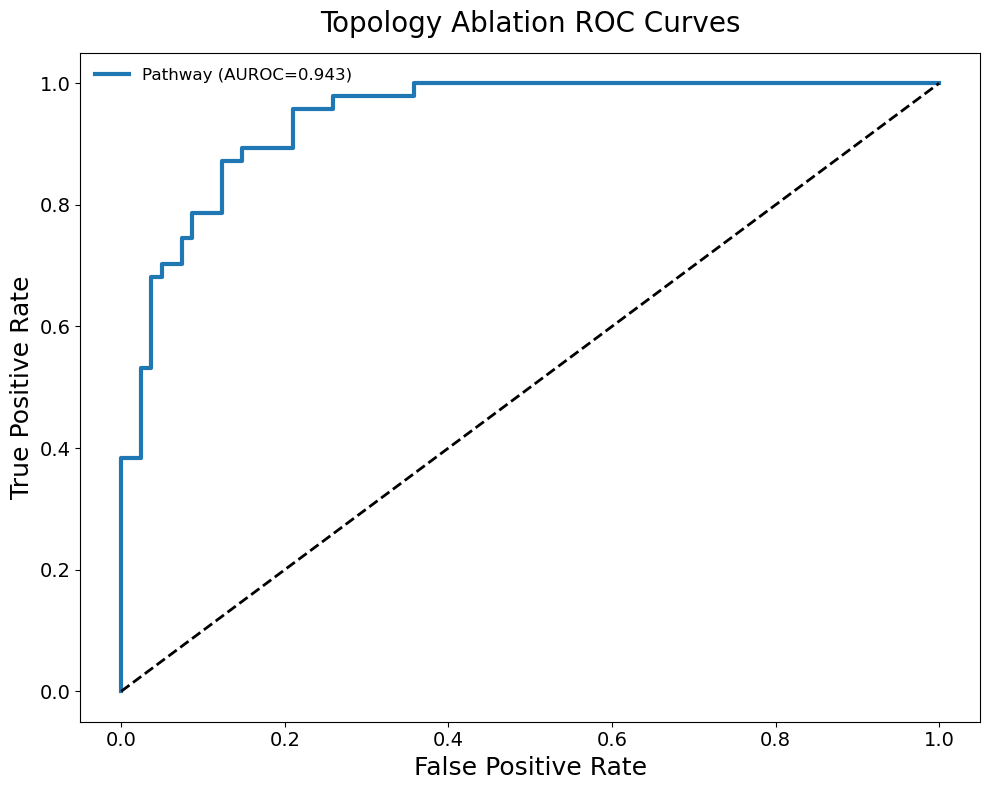

Saved: results/gene_prediction/topology_ablation_ROC.png


In [51]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# # =========================================================
# # NETWORK FILES
# # ========================================================= 

# NETWORKS = {

#     "Pathway":
#         "../process/data/processed/gene_pairs_limit5000.csv",

#     # "CPDB":
#     #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

#     # "HIPPIE":
#     #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

#     "STRING":
#         "../data/processed/STRING_gene_network.csv"
# }

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
cpdb_gene_names=np.array(
    list(cpdb_nodes.keys())
)

# labeled genes only
labeled_mask=(cpdb_labels!=-1)

cpdb_genes=cpdb_gene_names[
    labeled_mask.cpu().numpy()
]

cpdb_gene_labels=(
    cpdb_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "CPDB labeled genes:",
    len(cpdb_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        cpdb_genes,
        test_size=0.40,
        stratify=cpdb_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    cpdb_labels[
        cpdb_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)



# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=559 Val=186 Test=187
Epoch=0 Loss=0.0441 ValAUROC=0.9437
Epoch=10 Loss=0.0167 ValAUROC=0.9420
Epoch=20 Loss=0.0064 ValAUROC=0.9511
Epoch=30 Loss=0.0006 ValAUROC=0.9325
Early stopping at epoch 37


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5563  133259  23.954521  0.004306  0.956116   0.964864   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.948061  0.896552  0.903743  27.690217  

Saved: results/gene_prediction/topology_ablation.csv


,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5563,133259,23.954521,0.004306,0.956116,0.964864,0.948061,0.896552,0.903743,27.690217


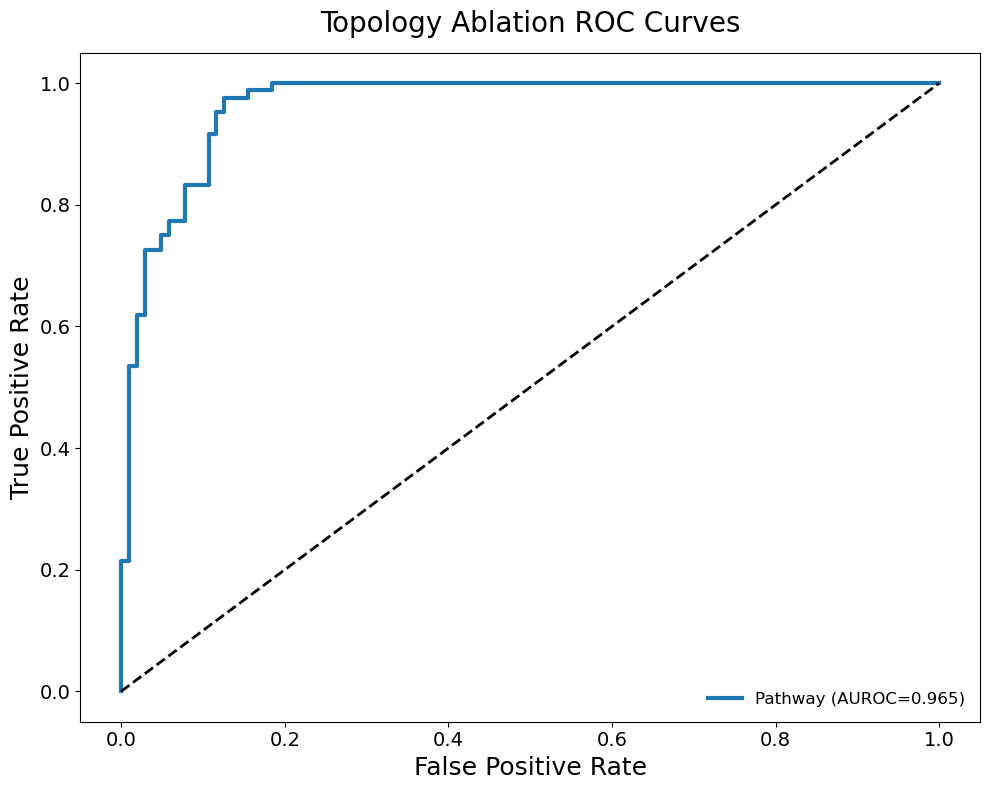

Saved: results/gene_prediction/topology_ablation_ROC.png


In [52]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================
#
# NOTE: The following are already defined:
#   source_csv_path, target_csv_path, MAX_EDGES_PER_NODE,
#   load_graph_data_directly, output_dir, device, args,
#   choose_model, FocalLoss, plt
#
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc
)

# # =========================================================
# # NETWORK FILES
# # =========================================================

# NETWORKS = {

#     "Pathway":
#         "../process/data/processed/gene_pairs_limit5000.csv",

#     # "CPDB":
#     #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

#     # "HIPPIE":
#     #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

#     "STRING":
#         "../data/processed/STRING_gene_network.csv"
# }

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
) = load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
cpdb_gene_names = np.array(
    list(cpdb_nodes.keys())
)

# labeled genes only
labeled_mask = (cpdb_labels != -1)

cpdb_genes = cpdb_gene_names[
    labeled_mask.cpu().numpy()
]

cpdb_gene_labels = (
    cpdb_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "CPDB labeled genes:",
    len(cpdb_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
#
# IMPORTANT: this split is done by GENE NAME, not by index.
# Each network gets its own node-index mapping built inside
# train_one_network(), so the same gene always lands in the
# same split regardless of how that network's loader orders
# its nodes.
# =========================================================

train_genes, temp_genes = (
    train_test_split(
        cpdb_genes,
        test_size=0.40,
        stratify=cpdb_gene_labels,
        random_state=42
    )
)

temp_labels = np.array([

    cpdb_labels[
        cpdb_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes, test_genes = (
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)


# =========================================================
# HELPER: map a list of gene names to node indices using a
# SPECIFIC network's own `nodes` dict (name -> index).
# Genes absent from this particular network are silently
# skipped (they simply can't be evaluated on that network).
# =========================================================

def genes_to_idx(gene_list, nodes_dict):

    idx = [
        nodes_dict[g]
        for g in gene_list
        if g in nodes_dict
    ]

    return torch.tensor(
        idx,
        dtype=torch.long
    )


# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    # ---- capture topology stats BEFORE self-loops are added,
    # so they reflect the real network rather than being
    # inflated by num_nodes synthetic self-loop edges ----
    raw_num_nodes = graph.number_of_nodes()
    raw_num_edges = graph.number_of_edges()

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        raw_num_edges
        /
        (raw_num_nodes ** 2)
    )

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor

    # =====================================================
    # BUILD MASKS FROM GLOBAL (NAME-BASED) SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # map this network's own gene -> index dict
    train_idx = genes_to_idx(train_genes, nodes)
    val_idx = genes_to_idx(val_genes, nodes)
    test_idx = genes_to_idx(test_genes, nodes)

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    node_labeled_mask = labels_tensor != -1

    train_mask &= node_labeled_mask
    val_mask &= node_labeled_mask
    test_mask &= node_labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)

    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    result = {

        "Network":
            network_name,

        "Nodes":
            raw_num_nodes,

        "Edges":
            raw_num_edges,

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }

    return result


# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

results_df = pd.DataFrame([
    {
        k: v
        for k, v in r.items()
        if k not in ["y_true", "y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

plt.figure(
    figsize=(10, 8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)
  
plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=398 Val=117 Test=128
Epoch=0 Loss=0.0441 ValAUROC=0.9178
Epoch=10 Loss=0.0140 ValAUROC=0.9197
Epoch=20 Loss=0.0024 ValAUROC=0.9231
Epoch=30 Loss=0.0001 ValAUROC=0.9169
Early stopping at epoch 36


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5563  138822  24.954521  0.004486  0.935243   0.952719   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.921739  0.807692   0.84375  27.137984  

Saved: results/gene_prediction/topology_ablation.csv


,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5563,138822,24.954521,0.004486,0.935243,0.952719,0.921739,0.807692,0.84375,27.137984


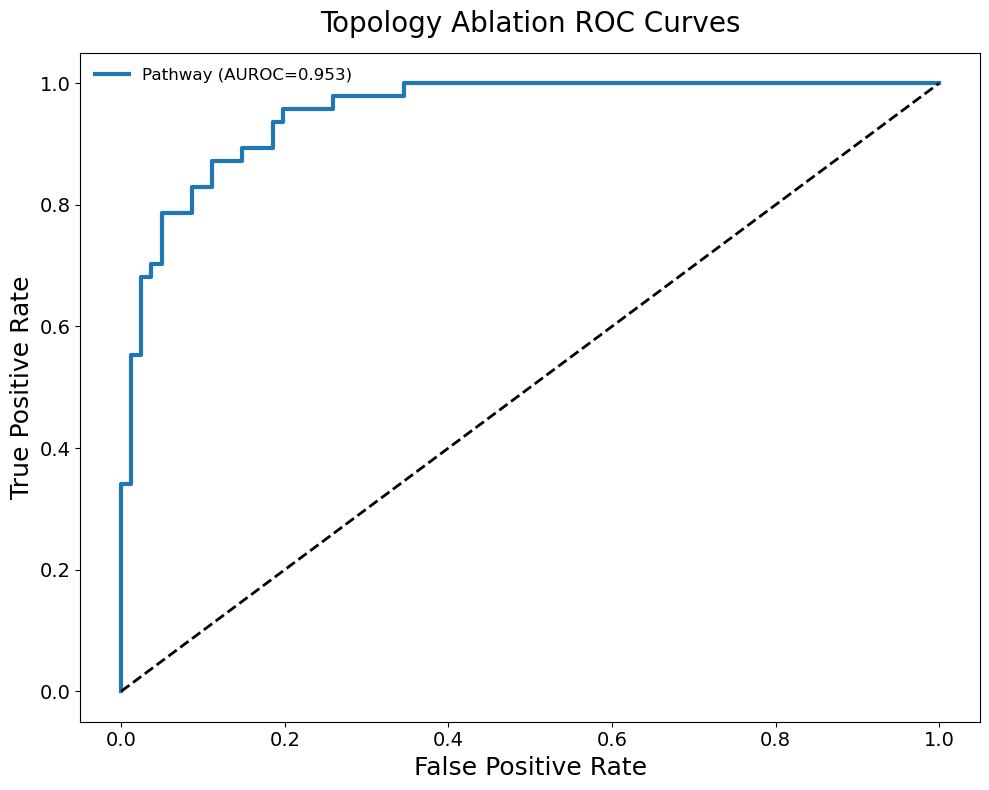

Saved: results/gene_prediction/topology_ablation_ROC.png


In [53]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# # =========================================================
# # NETWORK FILES
# # =========================================================

# NETWORKS = {

#     "Pathway":
#         "../process/data/processed/gene_pairs_limit5000.csv",

#     # "CPDB":
#     #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

#     # "HIPPIE":
#     #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

#     "STRING":
#         "../data/processed/STRING_gene_network.csv"
#         ../../ACGNN_data/data/multiomics_meth/CPDB_omics_ppi_embeddings_graph_2048.json
# }

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
cpdb_gene_names=np.array(
    list(cpdb_nodes.keys())
)

# labeled genes only
labeled_mask=(cpdb_labels!=-1)

cpdb_genes=cpdb_gene_names[
    labeled_mask.cpu().numpy()
]

cpdb_gene_labels=(
    cpdb_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "CPDB labeled genes:",
    len(cpdb_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        cpdb_genes,
        test_size=0.40,
        stratify=cpdb_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    cpdb_labels[
        cpdb_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)


# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(200):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )



results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)

## topology_ablation_ROC

In [54]:
nodes, edges, embeddings, labels = load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/192623 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/262345 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/8461 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 262345

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/262345 [00:00<?, ?it/s]


[INFO] Skipped edges: 129086

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5563
Edges: 133259
Embedding tensor shape: torch.Size([5563, 2688])
Labels tensor shape: torch.Size([5563])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt


In [55]:
print(
    f"{network_name}: "
    f"train={train_mask.sum().item()} "
    f"val={val_mask.sum().item()} "
    f"test={test_mask.sum().item()}"
)

print(
    f"Nodes={graph.number_of_nodes()} "
    f"Labeled={(labels_tensor!=-1).sum().item()}"
)

Pathway: train=2457 val=819 test=820
Nodes=5809 Labeled=932


In [56]:
# ============================================================
# BUILD STRING GENE NETWORK FOR ASPIRE-GNN
# ============================================================

import pandas as pd
import networkx as nx

# ============================================================
# INPUT FILES
# ============================================================

STRING_LINKS = (
    "../../ASPIRE-GNN/data/string/9606.protein.links.v12.0.txt.gz"
)

STRING_INFO = (
    "../../ASPIRE-GNN/data/string/9606.protein.info.v12.0.txt.gz"
)

DRIVER_FILE = (
    "../../ASPIRE-GNN/data/processed/763_driver_genes.txt"
)

NONDRIVER_FILE = (
    "../../ASPIRE-GNN/data/processed/5263_non_driver_genes.txt"
)

OUTPUT_NETWORK = (
    "../../ASPIRE-GNN/data/processed/STRING_gene_network.csv"
)

OUTPUT_NODES = (
    "../../ASPIRE-GNN/data/processed/STRING_node_labels.csv"
)

MIN_SCORE = 700

# ============================================================
# LOAD DRIVER GENES
# ============================================================

drivers = pd.read_table(
    DRIVER_FILE,
    header=None
)[0].str.upper()

nondrivers = pd.read_table(
    NONDRIVER_FILE,
    header=None
)[0].str.upper()

drivers = set(drivers)
nondrivers = set(nondrivers)

print(
    f"Drivers: {len(drivers)}"
)

print(
    f"Non-drivers: {len(nondrivers)}"
)

# ============================================================
# LOAD STRING PROTEIN INFO
# ============================================================

print("\nLoading STRING info...")

info_df = pd.read_csv(
    STRING_INFO,
    sep="\t"
)

print(info_df.shape)

id_to_gene = dict(
    zip(
        info_df["#string_protein_id"],
        info_df["preferred_name"]
    )
)

# ============================================================
# LOAD STRING LINKS
# ============================================================

print("\nLoading STRING links...")

links_df = pd.read_csv(
    STRING_LINKS,
    sep=" "
)

print(links_df.shape)

# ============================================================
# FILTER HIGH CONFIDENCE
# ============================================================

links_df = links_df[
    links_df["combined_score"] >= MIN_SCORE
]

print(
    "High confidence edges:",
    len(links_df)
)

# ============================================================
# MAP TO GENE SYMBOLS
# ============================================================

links_df["Gene1"] = (
    links_df["protein1"]
    .map(id_to_gene)
)

links_df["Gene2"] = (
    links_df["protein2"]
    .map(id_to_gene)
)

links_df = links_df.dropna(
    subset=["Gene1", "Gene2"]
)

links_df["Gene1"] = (
    links_df["Gene1"]
    .astype(str)
    .str.upper()
)

links_df["Gene2"] = (
    links_df["Gene2"]
    .astype(str)
    .str.upper()
)

links_df = links_df[
    links_df["Gene1"] != links_df["Gene2"]
]

print(
    "Mapped gene interactions:",
    len(links_df)
)

# ============================================================
# BUILD NETWORKX GRAPH
# ============================================================

print("\nBuilding graph...")

G = nx.Graph()

for _, row in links_df.iterrows():

    G.add_edge(
        row["Gene1"],
        row["Gene2"],
        weight=row["combined_score"]
    )

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

# ============================================================
# KEEP LARGEST CONNECTED COMPONENT
# ============================================================

largest_cc = max(
    nx.connected_components(G),
    key=len
)

G = G.subgraph(
    largest_cc
).copy()

print(
    "\nLargest CC Nodes:",
    G.number_of_nodes()
)

print(
    "Largest CC Edges:",
    G.number_of_edges()
)

# ============================================================
# CREATE EDGE TABLE
# Edge label = 1 if either endpoint is a driver
# ============================================================

edge_rows = []

for u, v, data in G.edges(data=True):

    edge_label = int(
        (u in drivers) or
        (v in drivers)
    )

    edge_rows.append({

        "Gene1": u,

        "Gene2": v,

        "gene_type": edge_label,

        "weight": data.get(
            "weight",
            1
        )
    })

edge_df = pd.DataFrame(
    edge_rows
)

print("\nEdge table shape:")
print(edge_df.shape)

print(edge_df.head())

print(
    "\nPositive edges:",
    edge_df["gene_type"].sum()
)

print(
    "Negative edges:",
    len(edge_df)
    - edge_df["gene_type"].sum()
)

# ============================================================
# SAVE NETWORK
# ============================================================

edge_df.to_csv(
    OUTPUT_NETWORK,
    index=False
)

print(
    "\nSaved:",
    OUTPUT_NETWORK
)

# ============================================================
# NODE LABEL FILE
# ============================================================

node_rows = []

for gene in sorted(
    G.nodes()
):

    node_rows.append({

        "Gene":
            gene,

        "gene_type":
            1 if gene in drivers else 0
    })

node_df = pd.DataFrame(
    node_rows
)

node_df.to_csv(
    OUTPUT_NODES,
    index=False
)

print(
    "Saved:",
    OUTPUT_NODES
)

# ============================================================
# NETWORK SUMMARY
# ============================================================

print("\n===================================")

print(
    "STRING Network Summary"
)

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

print(
    "Drivers in network:",
    node_df["gene_type"].sum()
)

print(
    "Non-drivers:",
    len(node_df)
    -
    node_df["gene_type"].sum()
)

print("===================================")

Drivers: 763
Non-drivers: 5263

Loading STRING info...
(19699, 4)

Loading STRING links...
(13715404, 3)
High confidence edges: 473860
Mapped gene interactions: 473860

Building graph...
Nodes: 16201
Edges: 236930

Largest CC Nodes: 15882
Largest CC Edges: 236712

Edge table shape:
(236712, 4)
  Gene1      Gene2  gene_type  weight
0  ARF5      ACAP1          0     825
1  ARF5       COPA          0     718
2  ARF5  RAB11FIP3          0     952
3  ARF5      COPB2          0     752
4  ARF5       COPE          0     795

Positive edges: 42016
Negative edges: 194696

Saved: ../../ASPIRE-GNN/data/processed/STRING_gene_network.csv
Saved: ../../ASPIRE-GNN/data/processed/STRING_node_labels.csv

STRING Network Summary
Nodes: 15882
Edges: 236712
Drivers in network: 734
Non-drivers: 15148


In [57]:
# # ============================================================
# # DOWNLOAD + BUILD CPDB PPI NETWORK
# # ============================================================

# import os
# import gzip
# import requests
# import pandas as pd
# import numpy as np
# import networkx as nx
# import matplotlib.pyplot as plt

# # ============================================================
# # OUTPUT DIRECTORY
# # ============================================================

# OUTPUT_DIR = "./cpdb_network"

# os.makedirs(
#     OUTPUT_DIR,
#     exist_ok=True
# )

# # ============================================================
# # CPDB DOWNLOAD URL
# # ============================================================
# # Update if CPDB changes filenames

# CPDB_URL = (
#     "https://cpdb.molgen.mpg.de/download/ConsensusPathDB_human_PPI.gz"
# )

# CPDB_GZ = os.path.join(
#     OUTPUT_DIR,
#     "ConsensusPathDB_human_PPI.gz"
# )

# CPDB_TXT = os.path.join(
#     OUTPUT_DIR,
#     "ConsensusPathDB_human_PPI.txt"
# )

# # ============================================================
# # DOWNLOAD FILE
# # ============================================================

# if not os.path.exists(CPDB_GZ):

#     print("Downloading CPDB...")

#     r = requests.get(
#         CPDB_URL,
#         stream=True
#     )

#     r.raise_for_status()

#     with open(CPDB_GZ, "wb") as f:

#         for chunk in r.iter_content(
#             chunk_size=8192
#         ):
#             f.write(chunk)

#     print("Download complete.")

# else:

#     print("Using existing file.")

# # ============================================================
# # UNZIP
# # ============================================================

# if not os.path.exists(CPDB_TXT):

#     print("Extracting...")

#     with gzip.open(
#         CPDB_GZ,
#         "rb"
#     ) as fin:

#         with open(
#             CPDB_TXT,
#             "wb"
#         ) as fout:

#             fout.write(fin.read())

# # ============================================================
# # LOAD FILE
# # ============================================================

# print("\nLoading CPDB interactions...")

# ppi_df = pd.read_csv(
#     CPDB_TXT,
#     sep="\t",
#     low_memory=False
# )

# print("Shape:", ppi_df.shape)

# print("\nColumns:")
# print(ppi_df.columns.tolist())

# # ============================================================
# # AUTO DETECT INTERACTOR COLUMNS
# # ============================================================

# colA = None
# colB = None

# for c in ppi_df.columns:

#     lc = c.lower()

#     if (
#         "participant_a" in lc
#         or "protein_a" in lc
#         or "interactor_a" in lc
#         or lc.endswith("_a")
#     ):
#         colA = c

#     if (
#         "participant_b" in lc
#         or "protein_b" in lc
#         or "interactor_b" in lc
#         or lc.endswith("_b")
#     ):
#         colB = c

# if colA is None:
#     colA = ppi_df.columns[0]

# if colB is None:
#     colB = ppi_df.columns[1]

# print("\nUsing columns:")
# print(colA)
# print(colB)

# # ============================================================
# # CLEAN IDENTIFIERS
# # ============================================================

# def clean_gene(x):

#     if pd.isna(x):
#         return np.nan

#     x = str(x)

#     x = x.split(".")[0]

#     x = x.split("|")[0]

#     x = x.split(";")[0]

#     x = x.strip()

#     return x.upper()

# ppi_df["GeneA"] = ppi_df[colA].apply(
#     clean_gene
# )

# ppi_df["GeneB"] = ppi_df[colB].apply(
#     clean_gene
# )

# # ============================================================
# # REMOVE INVALID
# # ============================================================

# ppi_df = ppi_df.dropna(
#     subset=[
#         "GeneA",
#         "GeneB"
#     ]
# )

# ppi_df = ppi_df[
#     ppi_df["GeneA"] != ""
# ]

# ppi_df = ppi_df[
#     ppi_df["GeneB"] != ""
# ]

# # ============================================================
# # REMOVE SELF LOOPS
# # ============================================================

# ppi_df = ppi_df[
#     ppi_df["GeneA"] != ppi_df["GeneB"]
# ]

# # ============================================================
# # SORT EDGES
# # ============================================================

# ppi_df["Node1"] = np.minimum(
#     ppi_df["GeneA"],
#     ppi_df["GeneB"]
# )

# ppi_df["Node2"] = np.maximum(
#     ppi_df["GeneA"],
#     ppi_df["GeneB"]
# )

# ppi_df = ppi_df.drop_duplicates(
#     subset=[
#         "Node1",
#         "Node2"
#     ]
# )

# print(
#     "\nUnique interactions:",
#     len(ppi_df)
# )

# # ============================================================
# # SAVE EDGE LIST
# # ============================================================

# edge_file = os.path.join(
#     OUTPUT_DIR,
#     "cpdb_edges.csv"
# )

# ppi_df[
#     ["Node1", "Node2"]
# ].to_csv(
#     edge_file,
#     index=False
# )

# print(
#     "\nSaved:",
#     edge_file
# )

# # ============================================================
# # BUILD NETWORKX GRAPH
# # ============================================================

# print("\nBuilding graph...")

# G = nx.from_pandas_edgelist(

#     ppi_df,

#     source="Node1",

#     target="Node2"
# )

# print(
#     "Nodes:",
#     G.number_of_nodes()
# )

# print(
#     "Edges:",
#     G.number_of_edges()
# )

# # ============================================================
# # NETWORK STATISTICS
# # ============================================================

# degrees = dict(
#     G.degree()
# )

# degree_df = pd.DataFrame({

#     "Gene":
#         list(degrees.keys()),

#     "Degree":
#         list(degrees.values())
# })

# degree_df = degree_df.sort_values(

#     "Degree",
#     ascending=False
# )

# print("\nTop hub genes:")
# print(
#     degree_df.head(20)
# )

# # ============================================================
# # SAVE NODE STATS
# # ============================================================

# degree_file = os.path.join(
#     OUTPUT_DIR,
#     "cpdb_node_degree.csv"
# )

# degree_df.to_csv(
#     degree_file,
#     index=False
# )

# print(
#     "\nSaved:",
#     degree_file
# )

# # ============================================================
# # LARGEST COMPONENT
# # ============================================================

# largest_cc = max(

#     nx.connected_components(G),

#     key=len
# )

# G_cc = G.subgraph(
#     largest_cc
# ).copy()

# print(
#     "\nLargest component nodes:",
#     G_cc.number_of_nodes()
# )

# print(
#     "Largest component edges:",
#     G_cc.number_of_edges()
# )

# # ============================================================
# # DEGREE DISTRIBUTION
# # ============================================================

# plt.figure(
#     figsize=(8, 6)
# )

# plt.hist(

#     degree_df["Degree"],

#     bins=100
# )

# plt.xlabel(
#     "Degree"
# )

# plt.ylabel(
#     "Frequency"
# )

# plt.title(
#     "CPDB Degree Distribution"
# )

# plt.tight_layout()

# plt.savefig(

#     os.path.join(
#         OUTPUT_DIR,
#         "degree_distribution.png"
#     ),

#     dpi=300
# )

# plt.show()

# # ============================================================
# # TOP HUB GENES
# # ============================================================

# top_hubs = degree_df.head(30)

# plt.figure(
#     figsize=(10, 8)
# )

# plt.barh(

#     top_hubs["Gene"][::-1],

#     top_hubs["Degree"][::-1]
# )

# plt.xlabel(
#     "Degree"
# )

# plt.title(
#     "Top 30 CPDB Hub Genes"
# )

# plt.tight_layout()

# plt.savefig(

#     os.path.join(
#         OUTPUT_DIR,
#         "top_hubs.png"
#     ),

#     dpi=300
# )

# plt.show()

# # ============================================================
# # SAVE NETWORKX GRAPH
# # ============================================================

# graphml_file = os.path.join(
#     OUTPUT_DIR,
#     "cpdb_network.graphml"
# )

# nx.write_graphml(
#     G,
#     graphml_file
# )

# print(
#     "\nSaved GraphML:",
#     graphml_file
# )

# # ============================================================
# # SUMMARY
# # ============================================================

# print("\n====================================")
# print("CPDB NETWORK COMPLETE")
# print("====================================")

# print(
#     "Nodes:",
#     G.number_of_nodes()
# )

# print(
#     "Edges:",
#     G.number_of_edges()
# )

# print(
#     "Largest component:",
#     G_cc.number_of_nodes()
# )

# print(
#     "Output directory:",
#     OUTPUT_DIR
# )

In [58]:
# #
# # 
# # bash 

# mkdir -p data/string

# cd data/string

# wget https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz

# wget https://stringdb-downloads.org/download/protein.info.v12.0/9606.protein.info.v12.0.txt.gz

In [59]:
# ============================================================
# BUILD STRING GENE-GENE NETWORK
# ============================================================

import gzip
import pandas as pd
import networkx as nx

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------

STRING_LINKS = (
    "../../ASPIRE-GNN/data/string/9606.protein.links.v12.0.txt.gz"
)

STRING_INFO = (
    "../../ASPIRE-GNN/data/string/9606.protein.info.v12.0.txt.gz"
)

DRIVER_FILE = (
    "../../ASPIRE-GNN/data/processed/763_driver_genes.txt"
)

NONDRIVER_FILE = (
    "../../ASPIRE-GNN/data/processed/5263_non_driver_genes.txt"
)

OUTPUT_NETWORK = (
    "../../ASPIRE-GNN/data/processed/STRING_gene_network.csv"
)

OUTPUT_NODES = (
    "../../ASPIRE-GNN/data/processed/STRING_node_labels.csv"
)

LINK_FILE = "../../ASPIRE-GNN/data/string/9606.protein.links.v12.0.txt.gz"
INFO_FILE = "../../ASPIRE-GNN/data/string/9606.protein.info.v12.0.txt.gz"

MIN_SCORE = 700

# ============================================================
# LOAD PROTEIN INFO
# ============================================================

print("Loading STRING protein info...")

info_df = pd.read_csv(
    INFO_FILE,
    sep="\t"
)

print(info_df.shape)

# protein id -> gene symbol

id_to_gene = dict(
    zip(
        info_df["#string_protein_id"],
        info_df["preferred_name"]
    )
)

print("Mappings:", len(id_to_gene))

# ============================================================
# LOAD LINKS
# ============================================================

print("\nLoading STRING interactions...")

links_df = pd.read_csv(
    LINK_FILE,
    sep=" "
)

print(links_df.shape)

# ============================================================
# FILTER HIGH CONFIDENCE
# ============================================================

links_df = links_df[
    links_df["combined_score"] >= MIN_SCORE
]

print(
    "High-confidence interactions:",
    len(links_df)
)

# ============================================================
# MAP TO GENE SYMBOLS
# ============================================================

links_df["Gene1"] = (
    links_df["protein1"]
    .map(id_to_gene)
)

links_df["Gene2"] = (
    links_df["protein2"]
    .map(id_to_gene)
)

links_df = links_df.dropna(
    subset=["Gene1", "Gene2"]
)

links_df = links_df[
    links_df["Gene1"] != links_df["Gene2"]
]

print(
    "Gene-gene interactions:",
    len(links_df)
)

# ============================================================
# BUILD NETWORKX GRAPH
# ============================================================

print("\nBuilding graph...")

G = nx.Graph()

for _, row in links_df.iterrows():

    G.add_edge(
        row["Gene1"],
        row["Gene2"],
        weight=row["combined_score"]
    )

print("\nGraph statistics")

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

# ============================================================
# SAVE EDGE LIST
# ============================================================

edge_df = nx.to_pandas_edgelist(G)

edge_df.to_csv(
    "STRING_gene_network.csv",
    index=False
)

print(
    "\nSaved:",
    "STRING_gene_network.csv"
)

# ============================================================
# SAVE GRAPHML
# ============================================================

nx.write_graphml(
    G,
    "STRING_gene_network.graphml"
)

print(
    "Saved:",
    "STRING_gene_network.graphml"
)

# ============================================================
# TOP HUB GENES
# ============================================================

degree_df = pd.DataFrame({

    "Gene":
        list(dict(G.degree()).keys()),

    "Degree":
        list(dict(G.degree()).values())
})

degree_df = degree_df.sort_values(
    "Degree",
    ascending=False
)

print("\nTop 20 hub genes")

print(
    degree_df.head(20)
)

degree_df.to_csv(
    "STRING_hub_genes.csv",
    index=False
)

print(
    "\nSaved:",
    "STRING_hub_genes.csv"
)

Loading STRING protein info...
(19699, 4)
Mappings: 19699

Loading STRING interactions...
(13715404, 3)
High-confidence interactions: 473860
Gene-gene interactions: 473860

Building graph...

Graph statistics
Nodes: 16201
Edges: 236930

Saved: STRING_gene_network.csv
Saved: STRING_gene_network.graphml

Top 20 hub genes
        Gene  Degree
264     TP53     766
247   RPS27A     589
256    UBA52     521
1671    EGFR     506
459   CTNNB1     465
2830   H3C13     452
2824    H4C6     452
199     ACTB     438
46      AKT1     435
917      FAU     423
872    RPS18     421
2828   H3C12     413
367      SRC     407
965    RPS11     405
252      UBC     398
893     RPS9     397
785     MED1     395
620      TNF     391
2435   EP300     390
953     RPS3     387

Saved: STRING_hub_genes.csv


In [60]:
# =====================================================
# SAVE TOPOLOGY ABLATION RESULTS
# =====================================================

csv_file = os.path.join(
    output_dir,
    "topology_ablation_results.csv"
)

tex_file = os.path.join(
    output_dir,
    "topology_ablation_results.tex"
)

results_df.to_csv(
    csv_file,
    index=False
)

with open(tex_file, "w") as f:

    f.write(
        results_df.to_latex(
            index=False,
            float_format="%.4f",
            escape=True
        )
    )

print("Saved:", csv_file)
print("Saved:", tex_file)

Saved: results/gene_prediction/topology_ablation_results.csv
Saved: results/gene_prediction/topology_ablation_results.tex


In [61]:
# =====================================================
# SAVE MANUSCRIPT-STYLE LATEX TABLE
# =====================================================

tex_file = os.path.join(
    output_dir,
    "topology_ablation_results.tex"
)

df = results_df.copy()

# escape underscores
df["Network"] = (
    df["Network"]
    .astype(str)
    .str.replace("_", r"\_", regex=False)
)

with open(tex_file, "w") as f:

    f.write("\\begin{table}[t]\n")
    f.write("\\centering\n")
    f.write(
        "\\caption{Topology ablation study across biological networks.}\n"
    )
    f.write(
        "\\label{tab:topology_ablation}\n\n"
    )

    f.write(
        "\\begin{tabular*}{\\textwidth}"
        "{@{\\extracolsep{\\fill}}lcccccc}\n"
    )

    f.write("\\toprule\n")

    f.write(
        "\\textbf{Network} & "
        "\\textbf{Nodes} & "
        "\\textbf{Edges} & "
        "\\textbf{Test AUROC} & "
        "\\textbf{Test AUPRC} & "
        "\\textbf{F1} & "
        "\\textbf{Accuracy} \\\\\n"
    )

    f.write("\\midrule\n")

    for _, row in df.iterrows():

        f.write(
            f"{row['Network']} & "
            f"{int(row['Nodes'])} & "
            f"{int(row['Edges'])} & "
            f"{row['TestAUROC']:.4f} & "
            f"{row['TestAUPRC']:.4f} & "
            f"{row['F1']:.4f} & "
            f"{row['Accuracy']:.4f} \\\\\n"
        )

    f.write("\\bottomrule\n")
    f.write("\\end{tabular*}\n")
    f.write("\\end{table}\n")

print("Saved:", tex_file)

Saved: results/gene_prediction/topology_ablation_results.tex


In [62]:
# print("ASPIRE nodes:", len(nodes0))

# for network_name, relation_file in NETWORKS.items():

#     nodes_tmp, _, _, _ = load_graph_data_directly(
#         source_csv_path=source_csv_path,
#         target_csv_path=target_csv_path,
#         relation_csv_path=relation_file,
#         max_edges_per_node=MAX_EDGES_PER_NODE
#     )

#     print(
#         network_name,
#         len(nodes_tmp)
#     )

In [63]:
print("\nChecking overlap...")

network_genes = set(
    [str(x).upper() for x in node_names]
)

print("Network genes:", len(network_genes))
print("Train genes :", len(GLOBAL_TRAIN_GENES))

overlap_train = network_genes.intersection(
    GLOBAL_TRAIN_GENES
)

overlap_val = network_genes.intersection(
    GLOBAL_VAL_GENES
)

overlap_test = network_genes.intersection(
    GLOBAL_TEST_GENES
)

print("Train overlap:", len(overlap_train))
print("Val overlap  :", len(overlap_val))
print("Test overlap :", len(overlap_test))


Checking overlap...
Network genes: 5563
Train genes : 559
Train overlap: 0
Val overlap  : 0
Test overlap : 0
